<div style="border:solid green 2px; padding: 20px">
    
<b>Алексей, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Построение модели для прогнозирования стоимости подерженного автомобиля для перепродажи на вторичном рынке с целью автоматизации работы оценщиков компании AutoValue

- Автор: Федоров Алексей Анатольевич
- Дата: 06.09.2026

<a id='цели-и-задачи-проекта'></a>
## Цели и задачи проекта
AutoValue занимается оценкой и выкупом подерженных машин. Предварительную оценку стоимости для продажи и формирование цены выкупа, которую компания может предложить владельцу машины, в настоящее время формируют эксперты-оценщики в ручном режиме анализируя данные о машине. Однако, это занимает существенное время и требует много экспертов, поэтому труднее масштабировать такой подход.

Компания хочет, чтобы на основе предоставленных данных предварительная цена формировалась сразу, и клиент очень быстро получал рыночное предложение, которое не должно отклоняться от средней справедливой цены не более, чем на 20%. Это позволит удержать больше клиентов. Затем, оценка подтверждается очным осмотром машины техниками, после чего клиент, если его устраивает цена, сразу получает деньги на счёт. В случае большой ошибки в нижнюю сторону по цене выкупа, или долгого рассмотрения заявки клиент может уйти к конкурентам.

Однако, более важной при автоматической оценке цены выкупа является сдержанность. Чтобы модель не завышала цену более, чем на 20%. Иначе машину будет сложно продать с прибылью и компания будет нести убытки продавая в нуль или в минус.

Поэтому, в качестве фильтрационных ограничений введены бизнес две метрики, которым модель должна соотвествовать: **Overpricing Rate** (OR) и **Underpricing Loss** (UL). Это доля предсказаний, где цена выше реальной цены более, чем на 20% и, соотвествено, недополученная выручка:
$$
\text{Error Ratio} = \frac{\text{Предсказание} - \text{Реальность}}{\text{Реальность}}
$$


```
# Рассчитываем относительное отклонение
error_ratio = (preds - y_true) / y_true

# Считаем долю тех, где отклонение выше 20%
overpricing_rate = (error_ratio > 0.20).mean()

# Маска (фильтр) для случаев занижения цены на 20%+
under_mask = error_ratio < -0.20

# Суммируем разницу между реальной ценой и предсказанием для этих случаев
underpricing_loss = (y_true[under_mask] - preds[under_mask]).sum()
```

Для компании важно:
- ускорить оценку машин снизив влияние человеческого фактора и улучшив масштабируемость бизнеса, чтобы охватить больше клиентов;
- минимизировать Overpricing Rate, чтобы бизнес не работал в убыток;
- сохранить баланс с Underpricing Loss, чтобы клиенты не уходили к конкурентам из-за низких цен.



**1.** **Тип задачи** - регрессия, обучение с учителем (на размеченных данных).


**2.** **Задача** - на основе данных о машине, владельцах, её истории, состоянии спрогнозировать рыночную цену подержанной машины.


**3.** **Цель** - получить быструю автоматическую предварительную осторожную оценку цены подержанной машины так, чтобы не завысить цену и не получить убыток, но при этом и не занизить более 20%, чтобы не потерять клиента.


**4.** **Целевая переменная** - **`price_rub`**: рыночная стоимость автомобиля в рублях. Будем называть её TARGET.


**7.** **Модель** - ансамбль Decision Tree на основе градиентного бустинга: XGBoost, CatBoost или LightGBM.


**8.** **Метрики качества модели**
При обучении и отборе модели используем **ранжирующие** метрики.

 - **основная метрика:** - **MAE**, показывает среднюю ошибку цены в рублях, поэтому легко интерпретируема. MSE отвергаем, так как не хотим, чтобы модель сильно подстраивалась под редкие и дорогие машины;
 
 - **вспомогательные:** - **RMSE, R2** и бизнес-метрики **OR, UL**. Будем их логировать в user_attr и применять как фильтр, ограничивающий модели диапазоном допустимых значений метрик.


**9.** **Отбор лучшей модели:** - будем использовать принцип наименьшего ранга + фильтрацию по вспомогательным метрикам. По каждой метрике модели присваивается ранг начиная с 1, где 1 - это лучшее значение метрики. Ранги суммируются для одной модели по всем метрикам. Лучшая модель та, у кроторой мнимальный ранг.


**10.** **Особые условия отбора лучшей модели:** - необходимо обеспечить статистическую значимость сравнения моделей по MAE. Для этого будем требовать:
 - проводить попарное сравнение моделей с помощью парного t-теста по MAE на фолдах;
 - требовать p_value < 0.05 для объявления одной модели значимо лучше другой;
 - дополнительно требовать стабильность ошибки: std(MAE) / avg(MAE) <= 0.2 для каждой из сравниваемых моделей.


**11.** **Требования к модели**:
 - MAE < 100 000 руб;
 - R2 >= 0.85 (модель объясняет 85% дисперсии цены, либо более);
 - OR <= 5% (завышение цены моделью более, чем на 20% от реальной рыночной должно быть не более, чем в 5% случаев);
 - UL <= 3 000 000 на 1000 сделок;
 - std(MAE) / avg(MAE) ≤ 0.20 - стабильность на CV;
 - разница MAE между Train и Test <= 10% (нет переобучения);
 - время предсказания <= 5с.


<a id='описание-данных'></a>
## Описание данных
| Признак | Описание | Значимость для бизнеса |
|---------|----------|------------------------|
| **brand** | Марка автомобиля | Фундамент цены: престиж и надёжность бренда. |
| **make_year** | Год выпуска | Главный счётчик амортизации: чем старше автомобиль, тем дешевле. |
| **mileage_kmpl** | Пробег (км) | Реальный физический износ автомобиля. |
| **engine_cc** | Объём двигателя (в кубических см) | Влияет на мощность, налоги и интерес покупателей. |
| **fuel_type** | Тип топлива | Экономичность против мощности. Важный фактор ликвидности. |
| **transmission** | Тип коробки передач | «Автомат» или «механика» — ключевой фактор комфорта. |
| **owner_count** | Количество владельцев по ПТС | Юридическая чистота и аккуратность эксплуатации. |
| **color** | Цвет автомобиля | Психологический фактор: популярные цвета продаются быстрее. |
| **service_history** | Наличие сервисной книжки | Подтверждает, что за машиной ухаживали вовремя. |
| **accidents_reported** | Количество зафиксированных ДТП | Сильно бьёт по цене и безопасности будущей сделки. |
| **insurance_valid** | Действительна ли страховка | Снижает первичные расходы покупателя после сделки. |
| **region** | Макрорегион РФ, в котором продаётся автомобиль (Москва, Сибирь, Юг) | Позволяет модели учитывать региональную специфику цен. |
| **price_rub** | Целевой признак: рыночная стоимость автомобиля в рублях | Реальная сумма сделки, которую нужно предсказать. |


[ds_s16_train_data.csv](https://code.s3.yandex.net/datasets/ds_s16_train_data.csv) - обучающая выборка.

[ds_s16_test_data.csv](https://code.s3.yandex.net/datasets/ds_s16_test_data.csv) - тестовая выборка.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, вводная часть описана подробно

<a id='подготовка-среды-и-библиотек'></a>
## Подготовка среды и библиотек
### Зависимости
Самый правильный и 100% надёжный безпроблемный вариант - использовать venv + kernel. Это даёт полную изоляцию окружения для тетради, кроме того, собственную изолированную версию Python для venv, которую умеет ставить Conda:
```
conda create -y -n "${ENV_NAME}" python="${PYTHON_VERSION}"
```
Однако, ревьюверы почему-то не любят переключать ядра Jupyter, поэтому, будем использовать установку библиотек в домашнюю папку под Python 3.9. При этом не исключены конфликты версий.

#### Обновляем pip, чтобы работал --dry-run.

In [1]:
%pip install --upgrade --user --disable-pip-version-check -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple pip

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


In [2]:
# .local/lib/python3.9/site-packages должен стоять до глобального окружения
import sys
for p in sys.path:
    print(p)

/home/jovyan/work
/opt/conda/lib/python39.zip
/opt/conda/lib/python3.9
/opt/conda/lib/python3.9/lib-dynload

/home/jovyan/.local/lib/python3.9/site-packages
/opt/conda/lib/python3.9/site-packages
/opt/conda/lib/python3.9/site-packages/IPython/extensions
/home/jovyan/.ipython


In [3]:
%pip -V

pip 26.0.1 from /home/jovyan/.local/lib/python3.9/site-packages/pip (python 3.9)
Note: you may need to restart the kernel to use updated packages.


#### Проверяем наличие scikit-learn нужной версии через --dry-run.

In [4]:
%pip install --dry-run --only-binary=:all: --disable-pip-version-check scikit-learn==1.5.2 \
        -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.


Тут ставим зависимости. --user - ставит в домашнюю папку пользователя /home/xxx_user_name/.local/lib, а не в /opt/conda/lib. В sys.path прописана сначала папка пользователя, поэтому модули возьмутся оттуда.

--only-binary - не используется компиляция, а только Wheels - готовые бинарники.

In [5]:
%pip install --user --only-binary=:all: --disable-pip-version-check --no-warn-script-location \
    numpy==1.26.4 \
    scipy==1.13.1 \
    pandas==2.1.4 \
    scikit-learn==1.5.2 \
    matplotlib==3.8.2 \
    seaborn==0.13.0 \
    statsmodels==0.14.1 \
    phik==0.12.5 \
    jinja2==3.1.4 \
    numba==0.58.1 \
    llvmlite==0.41.1 \
    patsy==0.5.6 \
    joblib==1.4.2 \
    threadpoolctl==3.5.0 \
    optuna==3.6.1 \
    dill==0.3.8 \
    packaging==24.2 \
    ipywidgets==8.1.5 \
    xgboost==2.1.3 \
    catboost==1.2.7 \
    lightgbm==4.5.0 \
    "tqdm>=4.66" \
    shap==0.44.1 \
    -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


#### Проверяем, что встало

In [6]:
# Тест на ложную тревогу в логе pip по ipykernel 
import importlib.util, sys
spec = importlib.util.find_spec("ipykernel")
print("ipykernel найден:", spec is not None)
if spec:
    print("путь:", spec.origin)
import ipykernel
print("версия:", ipykernel.__version__)

ipykernel найден: True
путь: /opt/conda/lib/python3.9/site-packages/ipykernel/__init__.py
версия: 6.0.1


In [7]:
import sys, os
print(sys.version, '\n')
print(f"python      : {sys.version.split()[0]}\n")

import numpy, scipy, pandas, sklearn, optuna, dill, phik, numba, matplotlib, seaborn, statsmodels, tqdm

for m in (numpy, scipy, pandas, sklearn, optuna, dill, phik, numba, matplotlib, seaborn, statsmodels, tqdm):
    print(f"{m.__name__:18s} {m.__version__:12s} <- {m.__file__.split('site-packages')[0]}site-packages")

3.9.5 | packaged by conda-forge | (default, Jun 19 2021, 00:32:32) 
[GCC 9.3.0] 

python      : 3.9.5

numpy              1.26.4       <- /home/jovyan/.local/lib/python3.9/site-packages
scipy              1.13.1       <- /home/jovyan/.local/lib/python3.9/site-packages
pandas             2.1.4        <- /home/jovyan/.local/lib/python3.9/site-packages
sklearn            1.5.2        <- /home/jovyan/.local/lib/python3.9/site-packages
optuna             3.6.1        <- /home/jovyan/.local/lib/python3.9/site-packages
dill               0.3.8        <- /home/jovyan/.local/lib/python3.9/site-packages
phik               0.12.5       <- /home/jovyan/.local/lib/python3.9/site-packages
numba              0.58.1       <- /home/jovyan/.local/lib/python3.9/site-packages
matplotlib         3.8.2        <- /home/jovyan/.local/lib/python3.9/site-packages
seaborn            0.13.0       <- /home/jovyan/.local/lib/python3.9/site-packages
statsmodels        0.14.1       <- /home/jovyan/.local/lib/python3.

👉 Если тут ошибка, то **Нужен Restart Kernel !!!**

####  Удаление (очистка) установленных модулей
Этот код нужно раскомментить и выполнить после проверки работы или в случае проблем с установкой, если был непустой `/home/xxx_user_name/.local/lib/python3.9/site-packages/`

In [8]:
"""
import site, shutil, os, sys

user_site = site.getusersitepackages()
print("USER_SITE:", user_site)
print("Существует:", os.path.isdir(user_site))

if os.path.isdir(user_site):
    print("Содержимое (первые 40):")
    for name in sorted(os.listdir(user_site))[:40]:
        print("  ", name)
""";

In [9]:
"""
shutil.rmtree(user_site, ignore_errors=True)
print("Удалено. Перезапустите ядро: Kernel → Restart Kernel")
""";

### Импорты библиотек

In [10]:
# ============================== Standard ==============================
import contextlib
import gc
import inspect
import os
import sys
import time
import warnings
from dataclasses import dataclass, field, fields
from datetime import datetime
from functools import reduce
from itertools import combinations
from pprint import pprint
from typing import Protocol
from typing import Callable, Iterable, Protocol, Sequence, Optional, Any, List, Tuple

# ============================== Third-party ==================================
import dill
import joblib
import numpy as np
import pandas as pd
from joblib import Memory

from scipy.stats import normaltest, ttest_rel
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from IPython.display import HTML, Markdown, display, display_html

from tqdm import tqdm

# ============================== scikit-learn =================================
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import VarianceThreshold
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer,
)

from sklearn.model_selection import (
    cross_validate,
    cross_val_predict,
    train_test_split,
    KFold,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    KBinsDiscretizer,
)

# ============================== Boosting models ===============================
from xgboost import XGBRegressor
import xgboost as xgb

from catboost import CatBoostRegressor
import catboost as cb

import lightgbm as lgb 
from lightgbm import LGBMRegressor

import shap

<a id='общие-функции'></a>
### Общие функции
<a id='базовые'></a>
#### Базовые

In [11]:
def to_snake_case_columns(dataframe: pd.DataFrame) -> None:
    """Приводит названия колонок к snake_case прямо в исходном датафрейме."""
    dataframe.columns = (
        dataframe.columns
        .str.replace(r'[\s/()\-%,.]+', '_', regex=True)  # Замена спецсимволов и пробелов на _
        .str.replace(r'^_+|_+$', '', regex=True)         # Удаление подчеркиваний на концах
        .str.lower()                                     # Перевод в нижний регистр
    )
    
    
def get_integer_features_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Находит признаки, содержащие только целые числа (игнорируя NaN/пропуски),
    и возвращает DataFrame с их именами и кардинальностью.
    """
    integer_features = []
    cardinalities = []
    
    for col in dataframe.columns:
        # Удаляем пропуски для корректной проверки значений
        clean_col = dataframe[col].dropna()
        
        # Если колонка стала пустой после удаления NaN, пропускаем её
        if clean_col.empty:
            continue
            
        # Проверяем, является ли колонка числовой
        if pd.api.types.is_numeric_dtype(clean_col):
            # Проверяем, что все значения являются целыми (остаток от деления на 1 равен 0)
            if (clean_col % 1 == 0).all():
                integer_features.append(col)
                cardinalities.append(clean_col.nunique())
        else:
            # Если тип object/string, пробуем привести к числу
            try:
                converted = pd.to_numeric(clean_col)
                if (converted % 1 == 0).all():
                    integer_features.append(col)
                    cardinalities.append(converted.nunique())
            except (ValueError, TypeError):
                continue
                
    # Формируем итоговый DataFrame
    result_df = pd.DataFrame({
        'feature_name': integer_features,
        'cardinality': cardinalities
    })
    
    return result_df
    
def downcast_columns_for_ml(data_frame, *, ints=None, floats=None, cats=None):
    """Приводит колонки к оптимальным NumPy-типам для ML с downcast.

    - Integer колонки: int64 -> int8/16/32/64 в зависимости от диапазона.
    - Float колонки: float64 -> float32.
    - Object/String колонки: object -> category (для экономии памяти и ML).

    ВАЖНО: В отличие от Extended-типов pandas, стандартные целочисленные типы
    NumPy (int8-int64) НЕ поддерживают NaN. Если в целочисленной колонке есть
    пропуски, pandas принудительно оставит её в типе float32/64.
    """

    ints_actual = (
        set(ints) if ints is not None
        else set(data_frame.select_dtypes(include="integer").columns)
    )
        
    floats_actual = (
        set(floats) if floats is not None
        else set(data_frame.select_dtypes(include="float").columns)
    ) - ints_actual    
    
    cats_actual = (
        set(cats) if cats is not None
        else set(data_frame.select_dtypes(include=["object", "string"]).columns)
    )

    for col in ints_actual:
        # Приводим к числовому типу NumPy
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")

        # Если в колонке есть NaN, NumPy int не сможет её сохранить.
        # В таком случае переводим её во float32, чтобы не ломать ML-алгоритмы.
        if data_frame[col].isnull().any():
            data_frame[col] = data_frame[col].astype(np.float32)
            continue

        col_min, col_max = data_frame[col].min(), data_frame[col].max()

        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype(np.int32)
        else:
            data_frame[col] = data_frame[col].astype(np.int64)

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")
        data_frame[col] = data_frame[col].astype(np.float32)

    # Для ML текстовые признаки переводим в категориальный тип, а не в string
    for col in cats_actual:
        data_frame[col] = data_frame[col].astype("category")

    return data_frame

<a id='базовый-eda'></a>
#### Базовый EDA

In [12]:
def get_missings(df, hide_zeros = False):
    missing_df = df.isna().sum().to_frame(name='missing_count')
    missing_df['missing_percent'] = (df.isna().mean() * 100).round(2)
    if hide_zeros:
        missing_df = missing_df.query('missing_percent > 0')
    
    return missing_df.sort_values(by='missing_percent', ascending=False)

def get_missing_rows_info(dataframe: pd.DataFrame) -> dict:
    """Возвращает количество и процент строк, содержащих хотя бы один пропуск."""
    missing_mask = dataframe.isna().any(axis=1)
    
    total_missing = missing_mask.sum()
    percent_missing = (missing_mask.mean() * 100).round(2)
    
    return {
        'missing_rows_count': total_missing,
        'missing_rows_percent': percent_missing
    }
            
def get_whiskers(values, coeff=1.5, left=None, right=None):
    """
        Возвращает усы ящика для серии values.
    """
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    
    w_left = Q1 - coeff * IQR
    w_right = Q3 + coeff * IQR
    
    if left is not None:
        w_left = max(left, w_left)
    if right is not None:
        w_right = min(right, w_right)
        
    return w_left, w_right            
            
def get_reference_info(df, name, numeric=False, limit = 50):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 50 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    len_values = len(values)
    lst = values.head(limit).to_list()
    
    elipsis = ', ...' if len_values > limit else ''
    display(Markdown(f"**{name}:** `{lst}{elipsis}` = **{len_values}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def get_quasi_consts_numeric(df, names, threshold=0.1):
    vs_quasi = VarianceThreshold(threshold=threshold)     
    numerical_data = df[list(names)]
    vs_quasi.fit(numerical_data)
    return [col for col, keep in zip(names, vs_quasi.get_support()) if not keep]

def get_quasi_consts_categories(df, names):
    return [col for col in list(names)
                      if df[col].value_counts(normalize=True).iloc[0] > 0.90]

def drop_columns_inplace_safe(df, cols):
    existing_cols = df.columns.intersection(cols)
    df.drop(columns=existing_cols, inplace=True)   
    
def str_to_binary(dataframe: pd.DataFrame, column: str, mapping: dict) -> None:
    """
    Преобразует бинарный текстовый признак в число на месте (inplace).
    mapping: {'holiday': 1, 'no holiday': 0}
    Значения вне mapping и пропуски -> NaN.
    dtype: int8, если пропусков нет, иначе float32 (совместимо с sklearn).
    """
    s = dataframe[column].map(mapping)
    dataframe[column] = s.astype('int8') if s.notna().all() else s.astype('float32')
    
def var_summary(df, target, col):
    agg = df.groupby(col)[target].agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        # доля нулевых TARGET в группе
        zero_share=lambda s: (s == 0).mean()
    )
    # длоя строк в группе
    agg['share_%'] = (agg['count'] / len(df) * 100).round(1)
    return agg.round(4)

def describe_date_column(series: pd.Series) -> pd.Series:
    return pd.Series({
        'count': series.count(),
        'missing': series.isna().sum(),
        'min': series.min(),
        'max': series.max(),
        'range_days': (series.max() - series.min()).days,
        'unique_periods': series.nunique(),
        'most_common': series.mode().iloc[0] if not series.mode().empty else None,
    })

#### Статистический анализ

In [13]:
def print_high_corr_phik_pairs(phik_corr, threshold=0.7, sig_matrix=None, sig_threshold=3):
    """
    Выводит пары признаков с сильной связью по Phik (phik >= threshold).
    
    Параметры
    ----------
    phik_corr : pd.DataFrame
        Матрица Phik-корреляций (квадратная, симметричная).
    threshold : float
        Порог силы связи (Phik всегда в [0, 1], без знака).
    sig_matrix : pd.DataFrame, optional
        Матрица значимости (Z-score). Если передана — отфильтровывает
        ненадёжные пары (Z <= sig_threshold) и помечает их в выводе.
    sig_threshold : float
        Порог значимости (по умолчанию 3, что соответствует ~3 std).
    """
    print(f"\nСИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Phik >= {threshold}):")
    print("-" * 75)

    pairs = phik_corr.unstack().reset_index()
    pairs.columns = ["Feature 1", "Feature 2", "Phik"]

    # Убираем диагональ и дублирующиеся пары (Phik симметричен, порядок не важен)
    pairs = pairs[pairs["Feature 1"] < pairs["Feature 2"]]

    high_corr_pairs = pairs[pairs["Phik"] >= threshold].sort_values(
        by="Phik", ascending=False
    ).reset_index(drop=True)

    # Добавляем значимость, если матрица передана
    if sig_matrix is not None:
        high_corr_pairs["Significance_Z"] = high_corr_pairs.apply(
            lambda row: sig_matrix.loc[row["Feature 1"], row["Feature 2"]], axis=1
        )
        high_corr_pairs["Reliable"] = high_corr_pairs["Significance_Z"] > sig_threshold

    if not high_corr_pairs.empty:
        for _, row in high_corr_pairs.iterrows():
            line = f"{row['Feature 1']:22} <---> {row['Feature 2']:22} | Phik: {row['Phik']:.4f}"
            if sig_matrix is not None:
                mark = "✅" if row["Reliable"] else "⚠️ не значимо"
                line += f" | Z: {row['Significance_Z']:.1f} {mark}"
            print(line)
    else:
        print(f"✅ Сильно скоррелированных пар с Phik >= {threshold} не обнаружено.")

    print("-" * 75)

    return high_corr_pairs

#### Обучение

In [14]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object: tqdm):
    """Патч print_progress для отображения прогресса joblib через tqdm.

    Работает с joblib >= 1.3, где _print устарел. Актуально при n_jobs != 1;
    при последовательном выполнении прогресс лучше вести на уровне фолдов.
    """
    original = joblib.parallel.Parallel.print_progress

    def patched(self):
        tqdm_object.n = self.n_completed_tasks
        tqdm_object.refresh()
        return original(self)

    joblib.parallel.Parallel.print_progress = patched
    try:
        yield tqdm_object
    finally:
        joblib.parallel.Parallel.print_progress = original
        tqdm_object.close()

#### Графики

In [15]:
def plot_continuous_distributions(data_df, vars_list, kind="boxen", log_scale=False, bins="auto"):
    """
    Распределение непрерывных признаков: одна строка — одна переменная.
    Слева гистограмма с KDE, справа boxen/box на той же шкале X.

    kind      : 'boxen' (тяжёлые хвосты) | 'box' | 'violin'
    log_scale : True -> лог-шкала X (для правоскошенных величин)
    """
    nrows = len(vars_list)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 4.8 * nrows), squeeze=False,
                             gridspec_kw={"width_ratios": [1.6, 1]})

    for i, var in enumerate(vars_list):
        s = data_df[var].dropna()
        ax_l, ax_r = axes[i, 0], axes[i, 1]

        sns.histplot(x=s, bins=bins, kde=True, color="#4C72B0",
                     edgecolor="white", linewidth=0.3, ax=ax_l)
        ax_l.axvline(s.mean(), color="#C44E52", ls="--", lw=1.5, label=f"mean {s.mean():.1f}")
        ax_l.axvline(s.median(), color="#55A868", ls="-", lw=1.5, label=f"median {s.median():.1f}")
        ax_l.legend(fontsize=9)
        ax_l.set_title(f"Распределение: {var}", fontsize=13, pad=10, fontweight='bold')
        ax_l.set_ylabel("Count", fontsize=11)

        plot = {"boxen": sns.boxenplot, "box": sns.boxplot, "violin": sns.violinplot}[kind]
        plot(x=s, color="#4C72B0", ax=ax_r, **({"width": 0.4} if kind != "boxen" else {}))
        ax_r.scatter(s.mean(), 0, marker="D", s=45, color="#C44E52", zorder=10, label="mean")
        ax_r.legend(fontsize=9, loc="upper right")

        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
        ax_r.set_title(f"{kind}: {var} | выбросов по IQR: {n_out} ({n_out / len(s):.1%})",
                       fontsize=13, pad=10, fontweight='bold')
        ax_r.set_xlabel(var, fontsize=11)

        if log_scale:
            for ax in (ax_l, ax_r):
                ax.set_xscale("symlog")   # symlog, а не log: переносит нули

        stats = (f"n={len(s)}  zeros={(s == 0).sum()}  "
                 f"std={s.std():.1f}  skew={s.skew():.2f}  kurt={s.kurtosis():.2f}  "
                 f"min={s.min():.1f}  max={s.max():.1f}")
        ax_l.annotate(stats, xy=(0.5, -0.3), xycoords="axes fraction",
                      ha="center", fontsize=12, color="#555")

    plt.tight_layout()
    plt.show()

#### Настройки библиотек

In [16]:
memory = Memory(location='./cache_pipeline', verbose=0)

sns.set_theme(style="whitegrid") # светлосерая сетка
# warnings.filterwarnings("ignore")

warnings.filterwarnings(
    'ignore', message='Bins whose width are too small',
    category=UserWarning, module='sklearn.preprocessing._discretization')
warnings.filterwarnings(
    "ignore",
    message="Persisting input arguments took.*",
    category=UserWarning,
    module="joblib"
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [17]:
LOCAL_DATA_PATH = '/datasets/'
S3_DATA_PATH = 'https://code.s3.yandex.net/datasets/'
SEED = 42
TARGET = 'price_rub'

np.random.seed(SEED)

In [18]:
# ============================== Model requirements / thresholds ==============================

# --- Точность предсказания ---
MAE_THRESHOLD: float = 100_000.0          # MAE должен быть строго меньше 100 000 руб
R2_THRESHOLD: float = 0.85                 # R2 должен быть не менее 0.85 (>=)

# --- Бизнес-риск: завышение цены (Overpricing) ---
OVERPRICE_RATIO: float = 0.20              # порог завышения: предсказание выше факта более чем на 20%
OVERPRICE_RATE_THRESHOLD: float = 0.05     # доля таких случаев (OR) не должна превышать 5%

# --- Финансовые потери от завышения (Underwriting Loss / Upside Loss) ---
UL_THRESHOLD: float = 3_000_000.0          # суммарные потери на 1000 сделок, руб
UL_DEALS_BASE: int = 1_000                 # база расчёта — на сколько сделок нормируется UL

# --- Стабильность на кросс-валидации ---
CV_STABILITY_THRESHOLD: float = 0.20       # std(MAE) / mean(MAE) по фолдам <= 0.20

# --- Переобучение (Train vs Test) ---
TRAIN_TEST_MAE_GAP_THRESHOLD: float = 0.10 # относительная разница MAE между train и test <= 10%

# --- Производительность ---
PREDICTION_TIME_THRESHOLD: float = 5.0     # время предсказания должно быть строго меньше 5 секунд

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Интересные функции. Подскажи, ты где-то их нашел или это решение ИИ?

# Часть 1. EDA (Экспресс-анализ данных)

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

## Загрузка данных

### Общий код

In [19]:
class FileProto(Protocol):
    name: str
    description: str
    df: Optional[pd.DataFrame]    


class AutoValueFilesProto(Protocol):
    train: FileProto
    test: FileProto

@dataclass
class File(FileProto):
    name: str
    description: str
    df: Optional[pd.DataFrame] = None

@dataclass
class AutoValueFiles(AutoValueFilesProto):
    train: File = field(
        default_factory=lambda: File(
            name="ds_s16_train_data.csv",
            description="Обучающая выборка",
        )
    )

    test: File = field(
        default_factory=lambda: File(
            name="ds_s16_test_data.csv",
            description="Тестовая выборка",
        )
    )

In [20]:
def load_df(file_name):
    """
    1. Проверит есть ли CSV локально, и загрузит либо из локальной папки либо из S3.
    2. При загрузке сразу оптимизиует типы для дат и ID. ID будет преобразован в int32.
    """
    local_path = LOCAL_DATA_PATH + file_name
    s3_path = S3_DATA_PATH + file_name
    
    data_path = local_path if os.path.exists(local_path) else s3_path        
    
    df = pd.read_csv(
        data_path, 
        decimal='.', 
        sep=',', 
        skipinitialspace=True,
    )
    # помечаем датасет
    df.attrs['name'] = file_name    
    
    df_shape = df.shape
    print(f'✅ Датасет загружен с "{data_path}" содержит: {df_shape[0]} строк x {df_shape[1]} колонок')    
    
    return df

def pre_analyze_ds(df):  
    has_id = 'ID' in df.columns
    if has_id:
        print(f'ID уникален: {df["ID"].is_unique}')
    display(df.dtypes.to_frame(name='type'))
    display(df.head())
    
    print('Явные полные дубликаты:', df.duplicated().sum())
    if has_id:
        print('Дубликаты тела без ID:', df.duplicated(subset=[col for col in df.columns if col != 'ID']).sum())
        
    display(get_missings(df))

### Загрузка

In [21]:
data = AutoValueFiles()

for f in fields(data):
    file_object = getattr(data, f.name)     
    file_object.df = load_df(file_object.name)
    
empty_sum = sum(1 for f in fields(data) if getattr(data, f.name).df is None)
print('Загружены все файлы' if not empty_sum else f'Не загружено {empty_sum} файлов')

✅ Датасет загружен с "/datasets/ds_s16_train_data.csv" содержит: 8000 строк x 13 колонок
✅ Датасет загружен с "/datasets/ds_s16_test_data.csv" содержит: 2000 строк x 13 колонок
Загружены все файлы


### Предварительная подготовка данных и начальный EDA

#### Обучающая выборка

In [22]:
pre_analyze_ds(data.train.df)

,type
make_year,int64
mileage_kmpl,float64
engine_cc,int64
fuel_type,object
owner_count,int64
brand,object
transmission,object
color,object
service_history,object
accidents_reported,int64


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


Явные полные дубликаты: 0


,missing_count,missing_percent
make_year,0,0.0
mileage_kmpl,0,0.0
engine_cc,0,0.0
fuel_type,0,0.0
owner_count,0,0.0
brand,0,0.0
transmission,0,0.0
color,0,0.0
service_history,0,0.0
accidents_reported,0,0.0


In [23]:
# проверим значения численных признаков
display(data.train.df.describe().T)

,count,mean,std,min,25%,50%,75%,max
make_year,8000.0,2009.221250,8.388703,1995.0,2002.00,2009.00,2017.00,2023.0
mileage_kmpl,8000.0,17.946343,5.015565,5.0,14.53,17.97,21.35,35.0
engine_cc,8000.0,2289.687500,1289.812139,800.0,1200.00,2000.00,3000.00,5000.0
owner_count,8000.0,3.001125,1.419199,1.0,2.00,3.00,4.00,5.0
accidents_reported,8000.0,0.487875,0.693839,0.0,0.00,0.00,1.00,5.0
price_rub,8000.0,683647.872125,264923.498564,95000.0,493857.00,663866.00,855056.00,1676525.0


In [24]:
# проверим категориальные признаки
display(data.train.df.describe(include=['category', 'object']).T)

,count,unique,top,freq
fuel_type,8000,3,Petrol,3990
brand,8000,10,Nissan,870
transmission,8000,2,Manual,4812
color,8000,6,White,1366
service_history,8000,3,Full,3985
insurance_valid,8000,2,Yes,6356
region,8000,6,Юг,1408


#### Тестовая выборка

In [25]:
pre_analyze_ds(data.test.df)

,type
make_year,int64
mileage_kmpl,float64
engine_cc,int64
fuel_type,object
owner_count,int64
brand,object
transmission,object
color,object
service_history,object
accidents_reported,int64


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


Явные полные дубликаты: 0


,missing_count,missing_percent
make_year,0,0.0
mileage_kmpl,0,0.0
engine_cc,0,0.0
fuel_type,0,0.0
owner_count,0,0.0
brand,0,0.0
transmission,0,0.0
color,0,0.0
service_history,0,0.0
accidents_reported,0,0.0


In [26]:
# проверка нету ли расхождения колонок
print(data.test.df.columns.equals(data.train.df.columns))

True


#### Промежуточный вывод
Предоставлены данные, разбитые на обучающую и тестовую выборки. Данные соотвествуют`*` описанию и содержат 8000 и 2000 строк соотвественно, и 13 признаков. Наблюдения охватыват машины с 1995 по 2023 годы изготовления. Имена признаков в **Snake case**. Пропусков и дубликатов нет. Некорректных значений признаков не наблюдается. Типы данных соответсвуют описанию признаков, но завышены по разрядности и могут быть оптимизированы. Категориальные признаки имеют тип object. Это не оптимально с точки зрения потребления памяти, поэтому, надо преобразовать в category.

Наиболее частые параметры машин: толиво - бензин, цвет - белый, марка - Ниссан, регион - Юг и наличие полной сервисной истории.

`*` Исключение - признак **mileage_kmpl**. По описанию в данных это пробег машины в км, но по значениям это расход топлива на 100 км: 5 - 35 литров со средним 17. На пробег не похоже. 

#### Технический анализ категориальных признаков

In [27]:
PRE_CATEGORY_VARS = ('fuel_type', 'brand', 'transmission', 'color', 'service_history', 'region', 'insurance_valid')

In [28]:
for var in PRE_CATEGORY_VARS:
    get_reference_info(data.train.df, var)

**fuel_type:** `['Diesel', 'Electric', 'Petrol']` = **3**



,count,%
fuel_type,,
Petrol,3990,49.88
Diesel,3213,40.16
Electric,797,9.96



Пропущено: 0




**brand:** `['BMW', 'Chevrolet', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Nissan', 'Tesla', 'Toyota', 'Volkswagen']` = **10**



,count,%
brand,,
Nissan,870,10.88
Volkswagen,831,10.39
BMW,827,10.34
Honda,804,10.05
Chevrolet,800,10.00
Toyota,792,9.90
Hyundai,785,9.81
Tesla,784,9.80
Kia,765,9.56


...

,count,%
region,,
Юг,1408,17.60
Урал,1371,17.14
СПб,1346,16.83
Москва,1319,16.49
Дальний Восток,1295,16.19
Сибирь,1261,15.76



Пропущено: 0




**insurance_valid:** `['No', 'Yes']` = **2**



,count,%
insurance_valid,,
Yes,6356,79.45
No,1644,20.55



Пропущено: 0




✅ Категории целостны, не содержат неявных дубликатов, пропусков, имеют небольшие кардинальности. insurance_valid - бинарная колонка. Transmission тоже, но нет смысла её менять.

Теперь проверим соотвествие категорий в тестовой выборке.

In [29]:
for var in PRE_CATEGORY_VARS:
    train_vals = set(data.train.df[var].drop_duplicates().values)
    test_vals = set(data.test.df[var].drop_duplicates().values)
    print(f'{var:<25}: ', f'{train_vals == test_vals}')

fuel_type                :  True
brand                    :  True
transmission             :  True
color                    :  True
service_history          :  True
region                   :  True
insurance_valid          :  True


✅ Категориальные признаки совпадают по возможным значениям. Теперь можем разбить признаки на классы и оптимизировать типы данных под ML.

#### Начальная классификация признаков

In [30]:
BIN_VARS = ('insurance_valid', 'transmission')
CAT_VARS = ('fuel_type', 'brand', 'color', 'service_history', 'region',)
CONTINIOUS_VARS = ('mileage_kmpl',)
DISCRETE_VARS = ('make_year', 'engine_cc', 'owner_count', 'accidents_reported',)

In [31]:
all_columns_set = set(BIN_VARS) | set(CAT_VARS) | set(CONTINIOUS_VARS) | set(DISCRETE_VARS) | set([TARGET])
ds_columns_set = set(data.train.df.columns.values)
print('✅ Потерянных колонок нет' if all_columns_set == ds_columns_set else
      f'❌ потеряны колонки {ds_columns_set.difference(all_columns_set)}')

✅ Потерянных колонок нет


#### Оптимизация типов данных

In [32]:
print('Потребление памяти: ',
      f'{(data.train.df.memory_usage(deep=True).sum() + data.test.df.memory_usage(deep=True).sum()) / 1024:,.2f} Kb')

Потребление памяти:  5,155.59 Kb


In [33]:
downcast_columns_for_ml(
    data.train.df, 
    ints=data.train.df.select_dtypes(include='int64').columns.tolist(),     
    floats=data.train.df.select_dtypes(include='float64').columns.tolist(),
    cats=CAT_VARS
);
downcast_columns_for_ml(
    data.test.df, 
    ints=data.test.df.select_dtypes(include='int64').columns.tolist(),     
    floats=data.test.df.select_dtypes(include='float64').columns.tolist(),
    cats=CAT_VARS
);

str_to_binary(data.train.df, 'insurance_valid', {'Yes': 1, 'No': 0})
str_to_binary(data.test.df, 'insurance_valid', {'Yes': 1, 'No': 0})

str_to_binary(data.train.df, 'transmission', {'Automatic': 1, 'Manual': 0})
str_to_binary(data.test.df, 'transmission', {'Automatic': 1, 'Manual': 0})

print(data.train.df.dtypes)

make_year                int16
mileage_kmpl           float32
engine_cc                int16
fuel_type             category
owner_count               int8
brand                 category
transmission              int8
color                 category
service_history       category
accidents_reported        int8
insurance_valid           int8
price_rub                int32
region                category
dtype: object


In [34]:
print('Потребление памяти после оптимизации типов: ',
      f'{(data.train.df.memory_usage(deep=True).sum() + data.test.df.memory_usage(deep=True).sum()) / 1024:,.2f} Kb')

Потребление памяти после оптимизации типов:  210.94 Kb


✅ Выполнено преобразование типов данных. Потребление памяти снижено в 6.56 раза.

👉 Добавить в пайплайн.

#### Промежуточный вывод
**Загрузка данных:** Обучающая выборка содержит **8 000 строк × 13** колонок, тестовая — **2 000 строк × 13** колонок. Структура колонок в обоих датасетах идентична.

**Качество данных:**

- пропуски отсутствуют во всех признаках (missing_count = 0);
- явные дубликаты отсутствуют.

**Категориальные признаки (fuel_type, brand, transmission, color, service_history, region):**

- не содержат пропусков и неявных дубликатов;
- имеют небольшую кардинальность (от 2 до 10 уникальных значений);
- множества значений в обучающей и тестовой выборках полностью совпадают.

**Целевая переменная (price_rub):**

- представлена в формате int64 (впоследствии оптимизирована до int32).

**Оптимизация типов данных:**

- целочисленные признаки приведены к минимальным типам (int8, int16, int32);
- вещественный признак mileage_kmpl оптимизирован до float32;
- категориальные признаки преобразованы в тип category;
- потребление памяти снижено с 5 155,59 KB до 785,56 KB (в 6,56 раза).

**Итог:**

Данные полностью готовы к дальнейшему анализу — все признаки классифицированы, типы оптимизированы, выбросы и пропуски отсутствуют.

### Разделение на выборки¶

In [35]:
N_SPLITS: int = 5
VALID_SIZE: float = 0.2
    
CV_STD_LIMIT: float = 0.20         # допустимый std(MAE)/mean(MAE)

CV = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

X_full = data.train.df.drop(TARGET, axis=1)
y_full = data.train.df[TARGET]

X_fit, X_val, y_fit, y_val = train_test_split(
    X_full, y_full, test_size=VALID_SIZE, random_state=SEED, shuffle=True,
)
X_fit_with_target = pd.concat(
    [X_fit, y_fit.rename(TARGET)],
    axis=1
)
X_test, y_test = data.test.df.drop(TARGET, axis=1), data.test.df[TARGET]

print(f'train_fit : {X_fit.shape[0]:>5}  (Optuna, {N_SPLITS}-fold CV внутри)')
print(f'valid     : {X_val.shape[0]:>5}  (независимый контроль)')
print(f'test      : {X_test.shape[0]:>5}  (финал, один раз)')

train_fit :  6400  (Optuna, 5-fold CV внутри)
valid     :  1600  (независимый контроль)
test      :  2000  (финал, один раз)


In [36]:
# проверим расхождение среднего между выборками
summary = pd.DataFrame({
    'fit': y_fit.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]),
    'val': y_val.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]),
})

summary['diff_%'] = (
    (summary['val'] - summary['fit'])
    / summary['fit'].replace(0, float('nan'))
    * 100
).map(lambda x: f'{x:.2f}%')

display(summary)

,fit,val,diff_%
count,6.400000e+03,1.600000e+03,-75.00%
mean,6.833634e+05,6.847859e+05,0.21%
std,2.660805e+05,2.603230e+05,-2.16%
min,9.500000e+04,9.500000e+04,0.00%
1%,1.500946e+05,1.189004e+05,-20.78%
5%,2.719034e+05,2.898303e+05,6.59%
25%,4.919482e+05,5.004425e+05,1.73%
50%,6.627005e+05,6.682145e+05,0.83%
75%,8.567530e+05,8.484600e+05,-0.97%
95%,1.158755e+06,1.143144e+06,-1.35%


✅ Разбиение на выборки выполнено. Расхождение среднего и по квантилям менее 2% за исключением квантилей 1 и 5.

### Детальный EDA (анализ признаков)

Сейчас нужно понять:
- какие признаки константные или квази-константные — не несут информации;
- какие признаки — шум, то есть не связаны с ценой. Отдельно отличаем «слабый, но статистически значимый сигнал»;
- какова форма связи с ценой — монотонная или нет. От этого зависит, допустимы ли **monotone_constraints** в бустингах, которые напрямую сдерживают завышение цены и работают на метрику OR, её улучшение;
- есть ли взаимодействия между признаками — то есть добавляет ли пара признаков дисперсию сверх суммы их одиночных вкладов. От этого зависит требуемая глубина деревьев и достижимость R² ≥ 0.85;
- подобрать кодирование признаков, чтобы дерево правильно строило порог.

Не рассматриваем:
- выбросы в признаках;
- перекос распределения (skew);
- масштабирование и логарифмирование.

Деревья инвариантны к любым монотонным преобразованиям признаков, а сплиты строятся по порядковым статистикам. Выбросы не влияют на структуру сплита. skew тоже не меняет. Дерево не использует градиентный спуск и метрики расстояния, поэтому масштабирование и логарифмирование не влияют на сплит. Пропусков в данных нет (установлено на предыдущем шаге), дубликатов нет, кардинальность категорий не превышает 10.

**Методы**

**eta²** (доля объяснённой дисперсии) — единая мера силы связи признака с ценой, применимая одинаково к числовым и категориальным признакам: числовые предварительно биннингуются по квантилям. Ловит любую зависимость, включая немонотонную. Заменяет собой IV, который для регрессии некорректен: он требует бинаризации таргета и при малом числе уникальных значений признака выдаёт завышенные значения, ошибочно похожие на утечку.

**p-value ANOVA** — проверка, что различие средних цен между группами не случайно. Критично для признаков с eta² в диапазоне 0.001–0.01: отделяет реальный слабый сигнал от шума.

**Δcell** в рублях и процентах — размах средней цены между бинами признака. Прямо сопоставим с бизнес-порогом ±20%: признак, двигающий среднюю цену меньше чем на 20%, физически не способен повлиять на OR и UL.

**Спирмен по бинам (monotone)** — направление и строгость монотонности связи. Вход для решения о monotone_constraints.

**PSI (Population Stability Index)** — проверка, что train/test-сплит репрезентативен и не создал перекоса в распределении признаков.

**Прирост eta² на парах признаков** — оценка неаддитивности (взаимодействий) сверх суммы одиночных вкладов, с отбрасыванием редких ячеек.

**phik-матрица** — поиск дублирующихся признаков. VIF не используется: для ансамблей мультиколлинеарность не искажает предсказания, а только размывает feature importance, поэтому удалять будем лишь явные дубли (phik > 0.9).

**Критерий достижимости целевого качества**

Сумма eta² по признакам даёт грубую оценку потолка R² при аддитивной модели. Если она заметно ниже требуемых 0.85, недостающая дисперсия может прийти только из взаимодействий. Если и там пусто — требование R² ≥ 0.85 недостижимо на данных, и это фиксируется как ограничение датасета, а не как недоработка моделирования.

**Что на выходе**
- обновлённые списки признаков;
- решение о monotone_constraints;
- оценка нужной глубины деревьев и стратегия кодирования категорий для каждой из трёх библиотек.

#### Целевая переменная

Целевая переменная - непрерывная, поэтому строим гистограмму, KDE и ящик с усами.

In [37]:
desc = y_fit.describe()

formatted = desc.apply(lambda x: f'{x:,.0f}' if x == desc['count'] else f'{x/1000:,.1f} тыс. руб.')
print(formatted.to_string())

count                6,400
mean       683.4 тыс. руб.
std        266.1 тыс. руб.
min         95.0 тыс. руб.
25%        491.9 тыс. руб.
50%        662.7 тыс. руб.
75%        856.8 тыс. руб.
max      1,676.5 тыс. руб.


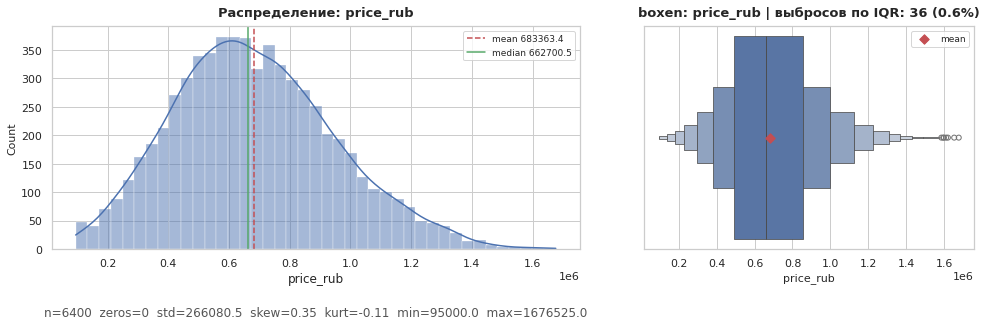

In [38]:
plot_continuous_distributions(X_fit_with_target, [TARGET])

Распределение целевой переменной price_rub близко к **нормальному:** слабая правая асимметрия (skew = 0.35), эксцесс практически нулевой (kurt = -0.11), среднее и медиана почти совпадают (683 363 vs 662 700, разница ~3%). Выбросов минимум — всего 45 наблюдений (0.6%) по правилу IQR, сосредоточены в области дорогих автомобилей и выглядят как реальный премиум-сегмент, а не ошибки данных. Диапазон значений (95 000 — 1 676 525 руб) адекватен. Наличие выбросов - ещё один довод в пользу применения MAE, как главной метрики.


**Вывод:** пока логарифмирование таргета не требуется — распределение почти симметрично, а используемые модели (XGBoost, CatBoost, LightGBM) не предъявляют требований к нормальности таргета. Решение о трансформации log1p(price_rub) с целью улучшения метрик можно приниматься экспериментально — по сравнению метрик MAE/RMSE/R2 baseline-модели на исходном и логарифмированном таргете. Это опциально, если метрики не будут дотягивать до заданных.

In [39]:
FEATURE_VARS: list[str] = list(BIN_VARS + CAT_VARS + CONTINIOUS_VARS + DISCRETE_VARS)
NUMERIC_VARS: list[str] = list(CONTINIOUS_VARS + DISCRETE_VARS)   # подлежат биннингу
NOMINAL_VARS: list[str] = list(BIN_VARS + CAT_VARS)               # группы as-is
ORDERED_VARS: list[str] = NUMERIC_VARS                            # имеют естественный порядок

# --- Пороги диагностики ---
BINS: int = 10                  # число квантильных бинов для числовых признаков
NOISE_ETA2: float = 0.01        # ниже — признак не объясняет дисперсию цены
NOISE_P: float = 0.05           # выше — различие средних статистически незначимо
LEAK_ETA2: float = 0.90         # выше — подозрение на утечку таргета
PSI_DRIFT: float = 0.25         # выше — распределение нестабильно между выборками
DUP_PHIK: float = 0.90          # выше — признаки дублируют друг друга
MONOTONE_MIN_ABS: float = 0.90  # минимальная строгость монотонности для constraints
MONOTONE_MIN_ETA2: float = 0.05 # ограничивать имеет смысл только значимый признак
INTERACTION_THR: float = 0.01   # прирост eta² выше — есть неаддитивность

In [40]:
def _feature_kind(col: str) -> str:
    """Семантический тип признака для отчёта."""
    if col in BIN_VARS:
        return 'bin'
    if col in CAT_VARS:
        return 'cat'
    if col in CONTINIOUS_VARS:
        return 'num'
    return 'disc'


def _binned(s: pd.Series, bins: int = BINS) -> pd.Series:
    """Приводит признак к дискретным строковым группам.

    Квантильный биннинг применяется только к числовым признакам с кардинальностью
    выше числа бинов. Бинарные и категориальные берутся как есть, независимо от dtype:
    insurance_valid и transmission имеют dtype int8, но семантически это флаги.

    Возвращает строки, а не Interval/Categorical: это позволяет склеивать
    группировки при анализе взаимодействий (ga + ' | ' + gb).
    """
    if s.name in NUMERIC_VARS and s.nunique() > bins:
        return pd.qcut(s, bins, duplicates='drop').astype(str)
    return s.astype(str)

def eta_squared(g: pd.Series, y: pd.Series) -> float:
    """Доля дисперсии TARGET, объяснённая группировкой (one-way ANOVA R²).

    Единая мера силы связи для числовых и категориальных признаков.
    < 0.01 шум | 0.01-0.05 слабый | 0.05-0.15 средний
    0.15-0.50 сильный | > 0.90 подозрение на утечку.
    """
    ss_total = float(((y - y.mean()) ** 2).sum())
    if ss_total == 0:
        return 0.0
    means = y.groupby(g, observed=True).transform('mean')
    return float(((means - y.mean()) ** 2).sum() / ss_total)


def anova_pvalue(g: pd.Series, y: pd.Series) -> float:
    """p-value one-way ANOVA: значимо ли различие средних TARGET между группами.

    Отделяет реальный слабый сигнал от случайного разброса на конечной выборке.
    Критично при eta² в диапазоне 0.001-0.01.
    """
    groups = [v.to_numpy() for _, v in y.groupby(g, observed=True) if len(v) > 1]
    return float(stats.f_oneway(*groups).pvalue) if len(groups) > 1 else 1.0


def monotone_score(s: pd.Series, g: pd.Series, y: pd.Series) -> float:
    """Спирмен между порядком бина и средним TARGET в бине.

    +1 строго растёт | -1 строго падает | ~0 немонотонно (U-образная / пиковая).
    Считается только для упорядоченных признаков: для бинарных и номинальных
    понятие монотонности не определено.
    Определяет допустимость monotone_constraints — защиты от завышения (метрика OR).
    """
    if s.name not in ORDERED_VARS:
        return np.nan

    # Порядок бинов берём из исходных значений, а не из строковых меток:
    # лексикографическая сортировка интервалов ненадёжна
    order_key = (
        pd.qcut(s, BINS, duplicates='drop')
        if s.nunique() > BINS
        else pd.Categorical(s, categories=sorted(s.unique()), ordered=True)
    )
    m = y.groupby(order_key, observed=True).mean().sort_index()
    if len(m) < 3:
        return np.nan
    return float(stats.spearmanr(np.arange(len(m)), m.to_numpy()).statistic)

def psi(base: pd.Series, current: pd.Series, bins: int = BINS) -> float:
    """Population Stability Index: < 0.1 стабилен | 0.1-0.25 дрейф | > 0.25 нестабилен.

    Ветвление по семантике, а не по dtype: бинарные и категориальные сравниваются
    по долям значений, числовые с высокой кардинальностью — по квантильным бинам.
    """
    if base.name not in NUMERIC_VARS or base.nunique() <= bins:
        b = base.astype('object').value_counts(normalize=True)
        c = current.astype('object').value_counts(normalize=True).reindex(b.index).fillna(0)
    else:
        edges = np.unique(np.nanquantile(base, np.linspace(0, 1, bins + 1)))
        if len(edges) < 3:
            return 0.0
        b = pd.Series(np.histogram(base, bins=edges)[0] / len(base))
        c = pd.Series(np.histogram(current, bins=edges)[0] / len(current))
    b, c = b.clip(1e-6), c.clip(1e-6)
    return float(((c - b) * np.log(c / b)).sum())

In [41]:
def profile_features(
    train: pd.DataFrame,
    reference: Optional[pd.DataFrame] = None,
    features: list[str] = FEATURE_VARS,
    target: str = TARGET,
    bins: int = BINS,
) -> pd.DataFrame:
    """Сводная диагностика признаков под GBDT-регрессию: сила связи, форма, стабильность.

    Parameters
    ----------
    train : pd.DataFrame
        Обучающая выборка. По ней считаются все метрики силы связи.
    reference : pd.DataFrame | None
        Выборка для расчёта PSI. Только из train — внутренний сплит или фолд CV.
        Тестовый файл передавать нельзя: это утечка информации о распределении
        признаков будущей партии данных. None → PSI не считается.
    features, target, bins
        Список признаков, имя целевой переменной, число квантильных бинов.

    Returns
    -------
    pd.DataFrame
        Строка на признак, отсортировано по убыванию eta².
        Колонки: тип, кардинальность, доля моды, eta², p-value ANOVA,
        размах средней цены между бинами (руб и %), монотонность, PSI,
        категория силы связи и итоговый вердикт.
    """
    absent = [c for c in features if c not in train.columns]
    if absent:
        raise KeyError(f'Признаки отсутствуют в train: {absent}')
    if reference is not None:
        absent_ref = [c for c in features if c not in reference.columns]
        if absent_ref:
            raise KeyError(f'Признаки отсутствуют в reference: {absent_ref}')

    y = train[target]
    mean_price = float(y.mean())
    rows: list[dict] = []

    for col in features:
        s = train[col]
        counts = s.astype('object').value_counts(normalize=True)

        if counts.empty:                      # колонка пуста — не роняем весь отчёт
            rows.append({
                'признак': col, 'тип': _feature_kind(col), 'nuniq': 0,
                'mode_%': np.nan, 'eta2': np.nan, 'p_anova': np.nan,
                'Δcell_тыс': np.nan, 'Δcell_%': np.nan,
                'monotone': np.nan, 'PSI': np.nan,
            })
            continue

        g = _binned(s, bins)
        cell_means = y.groupby(g, observed=True).mean()
        spread = float(cell_means.max() - cell_means.min())

        rows.append({
            'признак': col,
            'тип': _feature_kind(col),
            'nuniq': int(s.nunique()),
            'mode_%': round(counts.iloc[0] * 100, 1),
            'eta2': round(eta_squared(g, y), 4),
            'p_anova': anova_pvalue(g, y),
            'Δcell_тыс': round(spread / 1_000, 1),
            'Δcell_%': round(spread / mean_price * 100, 1),
            'monotone': round(monotone_score(s, g, y), 2),
            'PSI': (round(psi(s, reference[col], bins), 3)
                    if reference is not None else np.nan),
        })

    out = pd.DataFrame(rows).sort_values('eta2', ascending=False, ignore_index=True)

    out['сила'] = pd.cut(
        out['eta2'],
        [-1, NOISE_ETA2, 0.05, 0.15, 0.50, LEAK_ETA2, 1.01],
        labels=['шум', 'слабый', 'средний', 'сильный', 'оч.сильный', '⚠️утечка'],
    )
    out['вердикт'] = np.select(
        [
            out['nuniq'] == 0,
            out['nuniq'] == 1,
            out['mode_%'] > 99,
            out['eta2'] >= LEAK_ETA2,
            (out['eta2'] < NOISE_ETA2) & (out['p_anova'] > NOISE_P),
            out['PSI'] > PSI_DRIFT,
        ],
        [
            '❌ ПУСТАЯ КОЛОНКА → проверить преобразование',
            'КОНСТАНТА → drop',
            'квази-константа → drop',
            '⚠️ проверить на утечку',
            'ШУМ → кандидат на drop',
            'дрейф → проверить сплит',
        ],
        default='сигнал → оставить',
    )
    return out

#### Сравниваем показатели признаков

In [42]:
# Внутренний сплит train — имитация «новой партии» без обращения к тестовому файлу
_, val_inner = train_test_split(X_fit_with_target, test_size=0.2, random_state=SEED)

prof = profile_features(X_fit_with_target, reference=val_inner)

display(
    prof.style
    .background_gradient(subset=['eta2'], cmap='Blues')
    .format({'p_anova': '{:.2e}', 'monotone': '{:.2f}'}, na_rep='—')
)

print(f'Σ eta² по признакам : {prof["eta2"].sum():.3f}')
print(f'Требуемый R²        : {R2_THRESHOLD}')
print(f'Порог бизнес-риска  : Δcell_% должен превышать {OVERPRICE_RATIO:.0%}, '
      f'чтобы признак влиял на OR/UL')

,признак,тип,nuniq,mode_%,eta2,p_anova,Δcell_тыс,Δcell_%,monotone,PSI,сила,вердикт
0,engine_cc,disc,10,10.700000,0.462300,0.00e+00,588.600000,86.100000,1.00,0.006000,сильный,сигнал → оставить
1,make_year,disc,29,3.900000,0.179300,2.71e-266,355.000000,52.000000,1.00,0.003000,сильный,сигнал → оставить
2,fuel_type,cat,3,49.800000,0.093100,1.75e-136,271.200000,39.700000,—,0.001000,средний,сигнал → оставить
3,owner_count,disc,5,20.600000,0.072300,1.49e-102,203.400000,29.800000,-1.00,0.001000,средний,сигнал → оставить
4,mileage_kmpl,num,2004,0.600000,0.050100,2.16e-65,200.600000,29.400000,0.99,0.006000,средний,сигнал → оставить
5,color,cat,6,17.400000,0.001400,1.18e-01,31.800000,4.700000,—,0.002000,шум,ШУМ → кандидат на drop
6,brand,cat,10,10.900000,0.001200,5.37e-01,30.200000,4.400000,—,0.005000,шум,ШУМ → кандидат на drop
7,accidents_reported,disc,6,61.400000,0.001100,1.47e-01,188.500000,27.600000,-0.77,0.004000,шум,ШУМ → кандидат на drop
8,region,cat,6,17.400000,0.001000,2.51e-01,24.000000,3.500000,—,0.001000,шум,ШУМ → кандидат на drop
9,service_history,cat,3,49.600000,0.000300,3.71e-01,10.800000,1.600000,—,0.000000,шум,ШУМ → кандидат на drop


Σ eta² по признакам : 0.862
Требуемый R²        : 0.85
Порог бизнес-риска  : Δcell_% должен превышать 20%, чтобы признак влиял на OR/UL


👉 eta² показывает какую долю десперсии TARGET объясняет каждая переменная. В сумме объясняется 86.2% дисперсии, а с учётом взаимодействий пар, забегая вперёд (следующий тест),  0.908. Запас по требованиям есть, но всего 4%, поэтому, терять сигналы нельзя.

Сигналы сосредоточены в 5-ти признаках:
- engine_cc — 0.462, монотонный рост, размах 86% от средней цены;
- make_year — 0.179, монотонный рост, размах 52%;
- fuel_type — 0.093, единственная значимая категория, размах 40%;
- owner_count — 0.072, монотонное снижение, размах 30%;
- mileage_kmpl — 0.050, монотонный рост, размах 29%.

Все они превышают порог бизнес-риска в 20% при воздействии на цену TARGET, поэтому способны повлиять на OR и UL.

7 признаков имеют eta² ≤ 0.0016 при p_anova > 0.02. Это слабые и шумные признаки которые стоит проверить и возможно удалить.

4 числовых дискретных признака имеют (|ρ| ≥ 0.99, поэтому, строго монотонны и их можно применять с настройкой **monotone_constraints**, чтобы сделать модель более осторожной в плане OR (Overpricing Rate).

#### Взаимодействия признаков

In [43]:
def interaction_gain(
    df: pd.DataFrame,
    a: str,
    b: str,
    target: str = TARGET,
    bins: int = 4,
    min_cell: int = 40,
) -> float:
    """Прирост объяснённой дисперсии от пары признаков сверх суммы одиночных вкладов.

    > 0.02 → неаддитивность: нужна глубина деревьев ≥ 4 или явная interaction-фича.
    ≈ 0    → зависимость аддитивна, достаточно max_depth=3-4.
    Редкие ячейки отбрасываются: иначе прирост завышается переобучением на них.
    Число бинов снижено до 4, чтобы ячейки пары оставались наполненными.
    """
    y = df[target]
    ga, gb = _binned(df[a], bins), _binned(df[b], bins)
    pair = ga + ' | ' + gb
    mask = pair.map(pair.value_counts()) >= min_cell
    if mask.sum() < 200:
        return np.nan
    return round(
        eta_squared(pair[mask], y[mask])
        - eta_squared(ga[mask], y[mask])
        - eta_squared(gb[mask], y[mask]),
        4,
    )


def interaction_table(
    df: pd.DataFrame,
    prof: pd.DataFrame,
    target: str = TARGET,
    top: int = 6,
    threshold: float = INTERACTION_THR,
) -> pd.DataFrame:
    """Попарный прирост eta² среди топ-N сильнейших признаков."""
    strong = prof.nlargest(top, 'eta2')['признак'].tolist()
    rows = [
        {'пара': f'{a} × {b}', 'gain_eta2': gain}
        for i, a in enumerate(strong)
        for b in strong[i + 1:]
        if not np.isnan(gain := interaction_gain(df, a, b, target))
    ]
    out = pd.DataFrame(rows).sort_values('gain_eta2', ascending=False, ignore_index=True)
    out['вывод'] = np.where(out['gain_eta2'] > threshold, 'взаимодействие', 'аддитивно')
    return out


inter = interaction_table(X_fit_with_target, prof)
display(inter.style.background_gradient(subset=['gain_eta2'], cmap='Reds'))

ceiling = prof['eta2'].sum() + inter['gain_eta2'].clip(lower=0).sum()
verdict = 'достижим' if ceiling >= R2_THRESHOLD else '⚠️ НИЖЕ требуемого'
print(f'Максимальный прирост : {inter["gain_eta2"].max():.4f}')
print(f'Оценка потолка R²    : {ceiling:.3f} → {verdict} ({R2_THRESHOLD})')

,пара,gain_eta2,вывод
0,engine_cc × make_year,0.014100,взаимодействие
1,make_year × fuel_type,0.009100,аддитивно
2,engine_cc × fuel_type,0.008000,аддитивно
3,make_year × mileage_kmpl,0.004900,аддитивно
4,make_year × color,0.003000,аддитивно
5,fuel_type × color,0.001400,аддитивно
6,mileage_kmpl × color,0.001400,аддитивно
7,engine_cc × color,0.001100,аддитивно
8,fuel_type × owner_count,0.001000,аддитивно
9,owner_count × color,0.000900,аддитивно


Максимальный прирост : 0.0141
Оценка потолка R²    : 0.908 → достижим (0.85)


👉 eta-squared (η²) качественный прирост доли объяснённой дисперсии выше порога 0.01 даёт только пара признаков engine_cc × make_year. Остальные пары - только дают суммарный прирост объяснённой дисперсии. Поэтому, взаимодействия слабые. Одно парное взаимодействие требует глубины дерева 3 для сплита по engine_cc, а затем по make_year и ещё по одному признаку. Поэтому хватает **глубины дерева 4**. Для подбора глубины оптимально **`max_depth ∈ [3, 8]`**. Так как основной прирост качества будет не от взаимодействий признаков, а от одномерных зависимостей.

#### Коллинеарность, дублирующиеся признаки

In [44]:
corr = X_fit_with_target[FEATURE_VARS].phik_matrix(interval_cols=list(CONTINIOUS_VARS))

pairs = (
    corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    .stack()
    .sort_values(ascending=False)
    .rename('phik')
    .to_frame()
)
pairs['вывод'] = np.select(
    [pairs['phik'] > DUP_PHIK, pairs['phik'] > 0.70],
    ['ДУБЛЬ → drop одного', 'сильная связь → следить за importance'],
    default='норма',
)

print('Топ-10 пар признаков по phik:')
display(pairs.head(10).style.background_gradient(subset=['phik'], cmap='coolwarm'))

Топ-10 пар признаков по phik:


,,phik,вывод
fuel_type,make_year,0.078812,норма
mileage_kmpl,make_year,0.058705,норма
transmission,accidents_reported,0.057266,норма
service_history,make_year,0.050969,норма
fuel_type,region,0.049742,норма
region,accidents_reported,0.047421,норма
fuel_type,color,0.045712,норма
transmission,brand,0.044488,норма
fuel_type,mileage_kmpl,0.041385,норма
make_year,owner_count,0.041358,норма


👉 Максимальный phik = 0.079. Признаки полностью независимы, удалять по избыточности нечего.

#### Итоги

In [45]:
drop_hard = prof.loc[
    prof['вердикт'].isin(['КОНСТАНТА → drop', 'квази-константа → drop']), 'признак'
].tolist()
drop_soft = prof.loc[
    (prof['eta2'] < NOISE_ETA2) & (prof['p_anova'] > NOISE_P), 'признак'
].tolist()

KEEP_VARS = [c for c in FEATURE_VARS if c not in set(drop_hard) | set(drop_soft)]
KEEP_CAT = [c for c in KEEP_VARS if c in CAT_VARS]
KEEP_BIN = [c for c in KEEP_VARS if c in BIN_VARS]
KEEP_NUM = [c for c in KEEP_VARS if c in NUMERIC_VARS]

# Ограничения монотонности — только упорядоченные признаки с реальным сигналом
MONOTONE_CANDIDATES = {
    row['признак']: int(np.sign(row['monotone']))
    for _, row in prof.iterrows()
    if row['признак'] in ORDERED_VARS
    and pd.notna(row['monotone'])
    and abs(row['monotone']) >= MONOTONE_MIN_ABS
    and row['eta2'] >= MONOTONE_MIN_ETA2
}

print(f'Удаляем безусловно ({len(drop_hard)})     : {drop_hard or "—"}')
print(f'Кандидаты на drop, шум ({len(drop_soft)}) : {drop_soft or "—"}')
print(f'Оставляем ({len(KEEP_VARS)}) :')
print(f'  CAT : {KEEP_CAT}')
print(f'  BIN : {KEEP_BIN}')
print(f'  NUM : {KEEP_NUM}')
print(f'monotone_constraints : {MONOTONE_CANDIDATES or "—"}')

Удаляем безусловно (0)     : —
Кандидаты на drop, шум (7) : ['color', 'brand', 'accidents_reported', 'region', 'service_history', 'insurance_valid', 'transmission']
Оставляем (5) :
  CAT : ['fuel_type']
  BIN : []
  NUM : ['mileage_kmpl', 'make_year', 'engine_cc', 'owner_count']
monotone_constraints : {'engine_cc': 1, 'make_year': 1, 'owner_count': -1, 'mileage_kmpl': 1}


✅ Получены списки признаков для monotone_constraints и кандидатов на удаление, которые надо проверить через Ablation-тест. Запас по объяснению дисперсии TARGET всего 4%, поэтому терять сигнал нельзя. Диапазон max_depth для поиска — `[3, 8]`. 

#### Промежуточный вывод

**Кодирование признаков в пайплайне**

Все три библиотеки поддерживают категориальные признаки нативно, поэтому ручное кодирование (OHE, target encoding) не применяется. Признаки передаются в исходном виде dtype=category, различия ограничены способом их объявления: LightGBM определяет тип автоматически, XGBoost требует enable_categorical=True, CatBoost — списка cat_features. Такой подход исключает утечку через кодирование и позволяет каждому алгоритму применить оптимальную стратегию сплита.

| Признак | Тип | nuniq | Исходный dtype | Действие | LightGBM 4.5 | XGBoost 2.1 | CatBoost 1.2 |
|---------|-----|-------|----------------|----------|--------------|-------------|--------------|
| engine_cc | disc | 10 | int16 | без изменений | числовой сплит | числовой сплит | числовой сплит |
| make_year | disc | 29 | int16 | без изменений | числовой сплит | числовой сплит | числовой сплит |
| owner_count | disc | 5 | int8 | без изменений | числовой сплит | числовой сплит | числовой сплит |
| accidents_reported | disc | 6 | int8 | без изменений | числовой сплит | числовой сплит | числовой сплит |
| mileage_kmpl | num | 2108 | float32 | без изменений | числовой сплит | числовой сплит | числовой сплит |
| insurance_valid | bin | 2 | int8 | уже 0/1 | числовой сплит | числовой сплит | числовой сплит |
| transmission | bin | 2 | int8 | уже 0/1 | числовой сплит | числовой сплит | числовой сплит |
| fuel_type | cat | 3 | category | без изменений¹ | one-hot split | one-hot split | one-hot split |
| service_history | cat | 3 | category | без изменений¹ | one-hot split | one-hot split | one-hot split |
| color | cat | 6 | category | без изменений¹ | group split | partition | ordered TS |
| region | cat | 6 | category | без изменений¹ | group split | partition | ordered TS |
| brand | cat | 10 | category | без изменений¹ | group split | partition | ordered TS |


**monotone_constraints**

Применяем для получения более остоожной модели, чтобы не завышала TARGET и бизнес-метрика OR была бы ниже:
{'engine_cc': 1, 'make_year': 1, 'owner_count': -1, 'mileage_kmpl': 1}

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Проверены пропуски и дубликаты
* Категориальные значения train и test сверены
* Хорошо проработаны типы данных
* Анализ целевой переменной проводится на train

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Отбор признаков начинается до выделения независимой validation. Сначала признаки анализируются на всех 8000 объектах:

    prof = profile_features(data.train.df, reference=val_inner)

На основании этого анализа формируется список кандидатов на удаление:

    drop_soft = ...

И только позже исходные 8000 строк делятся на X_fit и X_val. Получается, будущие 1600 объектов validation уже участвовали в target-dependent анализе признаков через price_rub. После этого X_val нельзя считать полностью независимой выборкой для выбора модели.

Нужно изменить порядок:

* Сразу после первичной технической проверки разделить train на X_fit и X_val
* Все расчеты, влияющие на набор признаков - eta², ANOVA, отбор кандидатов, ablation - проводить только на X_fit
* X_val использовать только после фиксации набора признаков для сравнения конфигураций



<div class="alert alert-info"> <b>Комментарии студента:</b>
    
    Александр, но тут я формирую гипотезу по удалению, которая проверяется уже после разделения на выборки через Ablation тест на Train Set (на X_fit (6400 строк) через кросс-валидацию, без участия X_val), и потом уже идёт удаление.
    
    Вы полагаете, что анализ на полной EDA на полном Train ведёт к утечке, а утечка к переобучению.
    
    Но переобучение проверяется в конце работы по разнице MAE между Train и Test, она низкая: -0.47%. Признаков переобучения нет. Все работы выполнялись именно по такой последовательности разделения на выборки. В том числе, в ряде проектов это предписано шаблоном.
    
    Раннего разделения на выборки (до основного EDA) я не видел ни в одном проекте. Оно всегда после EDA. <b>Это то, что предписывает Яндекс в шаблонах.</b>
    Другое дело, что есть разные подходы. Например, использование обёрточных или фильтрационных методов отбора прямо в пайплане внутри CV.
    Но цифры показывают, что утечки нет. Если бы была утечка, то MAE резко падал бы на Test на >= 10%.
    
    Есть и ещё один аргумент: здесь я использую CV, а не отложенную выборку. Следовательно, если действовать на 200% строго, то весь анализ нужно переносить внутрь CV на каждый фолд отдельно. То есть, предлагаемое вами изменение не будет устанять утечку, о которой вы говорите.
    
    А на практике ручной EDA нельзя сделать внутри CV. Ну, только если вручную разбить на фолды и выполнить для каждого фолда заново. Это кратно увеличивает объём работы, поэтому, нужно только если падают метрики в разрядах выше допустимых.
    
    Ни в одном проекте так не делалось. Максимум - это обёрточный отбор признаков внутри пайплайнов. Например:
    `RFE(estimator=LogisticRegression(max_iter=1000), 
                n_features_to_select=20,  # оставить 20 признаков
                step=1))`.
    
    Но, кроме снижения прозрачности и роста вычислительной сложности, я пока не видел результата от этого.
    
    Наставники сказали: `Привет! Правильнее проводить до разделения на выборки, если выводить обобщенное правило, поскольку от такого анализа может зависеть как минимум принцип и подход к разделению на выборки. Таким образом ты видишь всю картину в целом. Как я уже говорил ранее в нашей сфере довольно мало каких то универсальных правил и подходов, всегда нужно отталкиваться от конкретной задачи. Например, может потребоваться дополнительны EDA на разделенных выборках для анализа на предмет соответствия распределений признаков.`
    
    
    👉 Я перенёс раздерение в конец базового EDA и дальше EDA на X_fit_with_target.
</div>

# Часть 2. Предобработка

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

👉 Начальную обработку выполнили в Предварительной подготовке. По результатам EDA дополнительной обработки (заполнения пропусков, дедубликации, нормализации, логарифмирования) не требуется. Переносим шаги Предварительной обработки в пайплайн.

## Метрики

In [46]:
def overpricing_rate(y_true: np.ndarray, y_pred: np.ndarray,
                     ratio: float = OVERPRICE_RATIO) -> float:
    """Доля наблюдений, где прогноз завышен более чем на ratio от реальной цены.

    Бизнес-риск: компания выкупает авто дороже рынка и теряет на перепродаже.
    """
    return float(np.mean(y_pred > y_true * (1 + ratio)))


def underpricing_loss(y_true: np.ndarray, y_pred: np.ndarray,
                      ratio: float = OVERPRICE_RATIO) -> float:
    """Суммарная недооценка в рублях там, где прогноз занижен более чем на ratio.

    Бизнес-риск: клиент уходит к конкуренту, компания теряет сделку.
    """
    mask = y_pred < y_true * (1 - ratio)
    return float((y_true[mask] - y_pred[mask]).sum())


def score_all(y_true, y_pred) -> dict[str, float]:
    """Полный набор метрик: качество прогноза + бизнес-риски."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': r2_score(y_true, y_pred),
        'OR_%': overpricing_rate(y_true, y_pred) * 100,
        'UL_млн': underpricing_loss(y_true, y_pred) / 1e6,
    }


# Направление оптимизации: True — чем меньше, тем лучше
METRIC_LOWER_BETTER: dict[str, bool] = {
    'MAE': True, 'RMSE': True, 'R2': False, 'OR_%': True, 'UL_млн': True,
}

In [47]:
@dataclass
class CVResult:
    """Результат кросс-валидации одной конфигурации модели."""
    name: str
    metrics: dict[str, float]
    mae_folds: np.ndarray
    fit_sec: float
    predict_sec: float
    params: dict = field(default_factory=dict)
    drop: list[str] = field(default_factory=list)

    @property
    def mae_cv_std_ratio(self) -> float:
        """std(MAE)/mean(MAE) по фолдам — критерий стабильности (порог 0.20)."""
        return float(self.mae_folds.std() / self.mae_folds.mean())

## Трансформеры и пайплан

### Трансформеры

In [48]:
class DowncastTransformer(BaseEstimator, TransformerMixin):
    """Приводит колонки к компактным типам: int8-64, float32, category.

    Границы диапазонов фиксируются на fit по обучающей выборке и применяются
    к валидации и тесту без пересчёта — иначе одна и та же колонка получит
    разный dtype в разных выборках, что ломает совместимость с бустингами.
    Категории также фиксируются: неизвестное значение в тесте станет NaN,
    и все три библиотеки обработают его штатно.
    """

    def __init__(self, ints=None, floats=None, cats=None):
        self.ints = ints
        self.floats = floats
        self.cats = cats

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)

        self.ints_ = [c for c in (self.ints or X.select_dtypes('integer').columns) if c in X]
        self.floats_ = [c for c in (self.floats or X.select_dtypes('float').columns)
                        if c in X and c not in self.ints_]
        self.cats_ = [c for c in (self.cats or X.select_dtypes(['object', 'string', 'category']).columns)
                      if c in X]

        self.int_dtypes_: dict[str, str] = {}
        for col in self.ints_:
            s = pd.to_numeric(X[col], errors='coerce')
            if s.isna().any():
                self.int_dtypes_[col] = 'float32'
                continue
            lo, hi = s.min(), s.max()
            for dtype, (d_lo, d_hi) in (
                ('int8', (-128, 127)),
                ('int16', (-32_768, 32_767)),
                ('int32', (-2_147_483_648, 2_147_483_647)),
            ):
                if lo >= d_lo and hi <= d_hi:
                    self.int_dtypes_[col] = dtype
                    break
            else:
                self.int_dtypes_[col] = 'int64'

        self.cat_dtypes_ = {
            col: pd.CategoricalDtype(categories=sorted(X[col].dropna().unique()))
            for col in self.cats_
        }
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = pd.DataFrame(X).copy()
        for col, dtype in self.int_dtypes_.items():
            if col in X:
                X[col] = pd.to_numeric(X[col], errors='coerce').astype(dtype)
        for col in self.floats_:
            if col in X:
                X[col] = pd.to_numeric(X[col], errors='coerce').astype('float32')
        for col, dtype in self.cat_dtypes_.items():
            if col in X:
                X[col] = X[col].astype(dtype)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features if input_features is not None
                          else self.feature_names_in_, dtype=object)

In [49]:
class BinaryMapper(BaseEstimator, TransformerMixin):
    """Преобразует строковые бинарные признаки в int8 (0/1) по словарю соответствий.

    Идемпотентна: колонка, уже приведённая к 0/1, не изменяется. Это защищает
    от повторного применения при перезапуске ячейки — иначе map по числам
    вернёт NaN и уничтожит колонку.
    Несопоставленные значения дают явную ошибку вместо тихого NaN.
    """

    def __init__(self, mappings: dict[str, dict[str, int]]):
        self.mappings = mappings

    def fit(self, X: pd.DataFrame, y=None):
        self.feature_names_in_ = list(pd.DataFrame(X).columns)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = pd.DataFrame(X).copy()
        for col, mapping in self.mappings.items():
            if col not in X:
                continue
            if set(X[col].dropna().unique()) <= set(mapping.values()):
                X[col] = X[col].astype('int8')
                continue
            mapped = X[col].astype('object').map(mapping)
            if mapped.isna().any():
                unmapped = set(X[col].astype('object').unique()) - set(mapping)
                raise ValueError(f'{col}: нет соответствия для {unmapped}')
            X[col] = mapped.astype('int8')
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features if input_features is not None
                          else self.feature_names_in_, dtype=object)

In [50]:
class CatToStr(BaseEstimator, TransformerMixin):
    """Приводит категориальные колонки к str — требование CatBoost 1.2.7.

    В этой версии dtype=category принимается нестабильно: поведение зависит
    от того, целочисленные или строковые значения лежат в категориях.
    """

    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.feature_names_in_ = list(pd.DataFrame(X).columns)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = pd.DataFrame(X).copy()
        for col in (c for c in self.cols if c in X):
            X[col] = X[col].astype(str)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features if input_features is not None
                          else self.feature_names_in_, dtype=object)

In [51]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Удаляет колонки по именам.
    Работает с pandas DataFrame, сохраняет имена признаков.    
    """
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop   # только присвоение (sklearn clone contract)

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)                    # что пришло
        self.feature_names_out_ = [c for c in X.columns
                                   if c not in self.cols_to_drop]   # что останется
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

    def get_feature_names_out(self, input_features=None):
        # приоритет: переданные имена -> сохранённые на fit
        if input_features is not None:
            return np.asarray([c for c in input_features
                               if c not in self.cols_to_drop], dtype=object)
        return np.asarray(self.feature_names_out_, dtype=object)

### Пайплайны

In [52]:
BIN_MAPPINGS: dict[str, dict[str, int]] = {
    'insurance_valid': {'Yes': 1, 'No': 0},
    'transmission': {'Automatic': 1, 'Manual': 0},
}
    
# отказались из-за малового влияния на MAE и поломки некоторых моделей
"""
MONOTONE: dict[str, int] = {
    'engine_cc': 1, 'make_year': 1, 'owner_count': -1, 'mileage_kmpl': 1,
}
"""

def _prep_steps(drop: Optional[list[str]]) -> list[tuple[str, Any]]:
    """Общая для всех моделей часть препроцессинга.

    Порядок обязателен: downcast создаёт category, binary приводит флаги к int8,
    dropper удаляет признаки последним — чтобы ablation не менял поведение
    предыдущих шагов и результаты оставались сопоставимыми.
    """
    steps: list[tuple[str, Any]] = [
        ('downcast', DowncastTransformer(cats=list(CAT_VARS))),
        ('binary', BinaryMapper(BIN_MAPPINGS)),
    ]
    if drop:
        steps.append(('dropper', ColumnDropper(list(drop))))
    return steps

"""
def _mono_list(drop: Optional[list[str]]) -> list[int]:
    # Ограничения монотонности как список по порядку колонок после drop.
    cols = [c for c in FEATURE_VARS if c not in set(drop or [])]
    return [MONOTONE.get(c, 0) for c in cols]


def _mono_dict(drop: Optional[list[str]]) -> dict[str, int]:
    # Ограничения монотонности как словарь — формат XGBoost.
    return {k: v for k, v in MONOTONE.items() if k not in set(drop or [])}
""";

In [53]:
def build_lgb(params: Optional[dict] = None, drop: Optional[list[str]] = None) -> Pipeline:
    """LightGBM: читает dtype=category автоматически, group split для >4 категорий.

    monotone_constraints не применяются: LightGBM запрещает их при objective='l1'
    (гессиан MAE вырожден, механизм ограничений на нём не реализован).
    Прямая оптимизация целевой метрики MAE приоритетнее, чем защита от завышения
    через ограничения — тем более что XGBoost и CatBoost их сохраняют,
    и разница в OR между библиотеками войдёт в сравнение как содержательный результат.
    """
    defaults = {
        'objective': 'l1',         
        'verbosity': -1,
        'random_state': SEED, 'n_jobs': -1,
    }
    return Pipeline(
        _prep_steps(drop) + [('model', lgb.LGBMRegressor(**{**defaults, **(params or {})}))],
        memory=memory,
    )

def build_xgb(params: Optional[dict] = None,
              drop: Optional[list[str]] = None,
              es_rounds: Optional[int] = None) -> Pipeline:
    """XGBoost: enable_categorical + tree_method='hist' обязательны для категорий.

    В версии 2.1 early_stopping_rounds задаётся в конструкторе, а не в fit.
    """
    defaults = {
        'objective': 'reg:absoluteerror', 
        'enable_categorical': True, 
        'tree_method': 'hist', # без него не работает enable_categorical
        'random_state': SEED, 'n_jobs': -1,
    }
    if es_rounds:
        defaults['early_stopping_rounds'] = es_rounds
        defaults['eval_metric'] = 'mae'
    return Pipeline(
        _prep_steps(drop) + [('model', xgb.XGBRegressor(**{**defaults, **(params or {})}))],
        memory=memory,
    )

def build_cb(params: Optional[dict] = None,
             drop: Optional[list[str]] = None) -> Pipeline:
    """CatBoost: ordered target statistics, категории объявляются через cat_features.

    Список cat_features фиксируется на этапе сборки с учётом drop —
    внутри Pipeline динамически передать его в fit невозможно.

    monotone_constraints не применяются: при loss_function='MAE' гессиан вырожден,
    ограничения блокируют выбор сплитов и модель деградирует до уровня хуже
    константы (проверено: MAE 257 784 против 76 324, R² = −0.52 против 0.87).
    Ошибку CatBoost при этом не выдаёт, в отличие от LightGBM,
    который такую комбинацию запрещает явно.
    """
    cats = [c for c in CAT_VARS if c not in set(drop or [])]
    defaults = {
        'loss_function': 'MAE',                         
        'verbose': False, 
        'random_seed': SEED,
        'cat_features': cats, 
        'allow_writing_files': False,
    }
    return Pipeline(
        _prep_steps(drop)
        + [('cat_str', CatToStr(cats)),
           ('model', CatBoostRegressor(**{**defaults, **(params or {})}))],
        memory=memory,
    )

def build_cb_quantile(alpha: float, params: Optional[dict] = None,
                      drop: Optional[list[str]] = None) -> Pipeline:
    """CatBoost с квантильной функцией потерь.

    alpha < 0.5 сдвигает предсказания вниз: штраф за завышение выше,
    чем за занижение. Ожидаемый эффект — падение OR, рост UL.

    Отличается от build_cb ровно одним параметром — loss_function.
    Все прочие настройки унаследованы, чтобы разница в бизнес-метриках
    объяснялась квантилем, а не сопутствующими изменениями регуляризации.
    """
    return build_cb(
        params={'loss_function': f'Quantile:alpha={alpha}', **(params or {})},
        drop=drop,
    )

def build_dummy(params: Optional[dict] = None, drop: Optional[list[str]] = None) -> Pipeline:
    """Baseline: медиана таргета. Медиана, а не среднее — соответствует MAE."""
    defaults = {'strategy': 'median'}
    return Pipeline(
        _prep_steps(drop) + [('model', DummyRegressor(**{**defaults, **(params or {})}))],
        memory=memory,
    )


BUILDERS: dict[str, Callable[..., Pipeline]] = {
    'Dummy': build_dummy,        # медиана таргета — точка отсчёта
    'LightGBM': build_lgb,       # objective='l1', монотонные ограничения запрещены библиотекой
    'XGBoost': build_xgb,        # reg:absoluteerror, монотонные ограничения убраны как нейтральные
    'CatBoost': build_cb,        # loss_function='MAE', монотонные ограничения вызывают деградацию
}

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* train/validation одинаковы для трех библиотек
* Test выделен отдельно
* Преобразования оформлены в пайплайнах
* Дамми использует медиану, что логично при MAE


# Часть 3. Обучение моделей в разных библиотеках

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

## Общие функции

In [54]:
def cv_predict_progress(pipe: Pipeline, X: pd.DataFrame, y: pd.Series,
                        cv=CV, desc: str = '', leave: bool = False) -> np.ndarray:
    """Out-of-fold предсказания с прогрессом по фолдам.

    Явный цикл вместо cross_val_predict: даёт прогресс при n_jobs=1
    и позволяет замерить время обучения каждого фолда отдельно.
    """
    oof = np.zeros(len(y), dtype=float)
    for tr, te in tqdm(list(cv.split(X)), desc=desc, leave=leave):
        est = clone(pipe)
        est.fit(X.iloc[tr], y.iloc[tr])
        oof[te] = est.predict(X.iloc[te])
    return oof

def evaluate_cv(name: str, builder: Callable, params: Optional[dict] = None,
                drop: Optional[list[str]] = None, X: pd.DataFrame = X_fit,
                y: pd.Series = y_fit, cv=CV, progress: bool = True) -> CVResult:
    """Оценка конфигурации по out-of-fold предсказаниям.

    Метрики считаются на OOF-предсказаниях целиком, а не усреднением по фолдам:
    для UL это принципиально — нужна сумма по всей выборке, а не среднее сумм.
    MAE дополнительно собирается пофолдово для оценки стабильности.
    """
    pipe = builder(params, drop)

    t0 = time.perf_counter()
    oof = (cv_predict_progress(pipe, X, y, cv, desc=name) if progress
           else cross_val_predict(pipe, X, y, cv=cv, n_jobs=1))
    fit_sec = (time.perf_counter() - t0) / cv.get_n_splits()

    mae_folds = np.array([
        mean_absolute_error(y.iloc[idx], oof[idx]) for _, idx in cv.split(X)
    ])

    pipe.fit(X, y)
    t0 = time.perf_counter()
    pipe.predict(X.head(1000))
    predict_ms = (time.perf_counter() - t0) * 1000

    return CVResult(
        name=name, metrics=score_all(y, oof), mae_folds=mae_folds,
        fit_sec=fit_sec, predict_sec=predict_ms,
        params=params or {}, drop=list(drop or []),
    )

In [55]:
RANK_METRICS: list[str] = ['MAE', 'RMSE', 'R2', 'OR_%', 'UL_млн']
CV_STD_LIMIT: float = 0.20          # порог std/mean MAE по фолдам
STABILITY_MAX: float = CV_STD_LIMIT * 100


def format_params(params: dict, per_line: int = 2) -> str:
    """Параметры в многострочный вид для HTML-таблицы.

    Разбивка по per_line пар на строку: длинная строка в одну линию
    обрезается элипсисом из-за CSS-переполнения ячейки даже при
    отключённом max_colwidth.
    """
    if not params:
        return '—'
    items = [f'{k}={v:.4g}' if isinstance(v, float) else f'{k}={v}'
             for k, v in sorted(params.items())]
    return '<br>'.join(
        ', '.join(items[i:i + per_line]) for i in range(0, len(items), per_line)
    )


def results_table(results: list[CVResult],
                  stages: Optional[dict[str, str]] = None,
                  rank_by: list[str] = RANK_METRICS,
                  drop_from_rank: tuple[str, ...] = ('Dummy',),
                  ) -> pd.DataFrame:
    """Сводная таблица с суммарным рангом по всем метрикам и гиперпараметрами.

    По каждой метрике модели ранжируются от лучшей (1) к худшей, ранги суммируются.
    Победитель — минимальная сумма: он сбалансирован по качеству и бизнес-риску,
    а не выигрывает по одной метрике ценой провала по другой.

    Нестабильные модели (std/mean MAE > CV_STD_LIMIT) исключаются из ранжирования:
    их поведение на новых данных непредсказуемо. Dummy исключается как точка отсчёта.

    stages — словарь {имя модели: этап} для колонки происхождения прогона.
    """
    stages = stages or {}
    df = pd.DataFrame([
        {'модель': r.name,
         'этап': stages.get(r.name, '—'),
         **r.metrics,
         'MAE_std/mean': r.mae_cv_std_ratio,
         'fit_сек': r.fit_sec,
         'predict_мс': r.predict_sec,
         'параметры': format_params(r.params)}
        for r in results
    ]).set_index('модель')

    df['стабильна'] = np.where(
        df['MAE_std/mean'] <= CV_STD_LIMIT, '✓', f'✗ >{CV_STD_LIMIT:.2f}')

    rankable = df.index[
        ~df.index.isin(drop_from_rank) & (df['MAE_std/mean'] <= CV_STD_LIMIT)
    ]
    ranks = pd.DataFrame(index=df.index, dtype=float)
    for m in rank_by:
        ranks[m] = df.loc[rankable, m].rank(
            ascending=METRIC_LOWER_BETTER[m], method='min')

    df['ранг'] = ranks.sum(axis=1)

    cols = ['этап', 'ранг', *RANK_METRICS, 'MAE_std/mean', 'стабильна',
            'fit_сек', 'predict_мс', 'параметры']
    return df[cols].sort_values('ранг', na_position='last')


def style_results(df: pd.DataFrame, caption: str = ''):
    """Оформление: градиенты по метрикам, перенос строк в колонке параметров."""
    num_fmt = {'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}',
               'OR_%': '{:.2f}', 'UL_млн': '{:.2f}', 'MAE_std/mean': '{:.3f}',
               'fit_сек': '{:.2f}', 'predict_мс': '{:.2f}', 'ранг': '{:.0f}'}
    st = (
        df.style
        .background_gradient(subset=['MAE', 'RMSE', 'OR_%', 'UL_млн'], cmap='RdYlGn_r')
        .background_gradient(subset=['R2'], cmap='RdYlGn')
        .background_gradient(subset=['ранг'], cmap='RdYlGn_r')
        .format(num_fmt, na_rep='—')
        .set_properties(subset=['параметры'], **{
            'white-space': 'pre-wrap', 'text-align': 'left',
            'font-size': '12px', 'font-family': 'monospace',
            'max-width': '340px', 'vertical-align': 'top'})
        .set_table_styles([
            {'selector': 'th', 'props': [('vertical-align', 'top')]},
            {'selector': 'td', 'props': [('vertical-align', 'top')]}])
    )
    return st.set_caption(caption) if caption else st

In [56]:
# Идемпотентная инициализация: перезапуск ячейки не теряет накопленное
if 'ALL_RESULTS' not in dir():
    ALL_RESULTS: dict[str, CVResult] = {}
    STAGES: dict[str, str] = {}


def remember(res: CVResult, stage: str) -> CVResult:
    """Регистрирует прогон в накопителе. Ключ = res.name, без суффиксов.

    Единый идентификатор во всех структурах избавляет от поиска
    по несовпадающим ключам на этапе выбора финальной модели.
    """
    ALL_RESULTS[res.name] = res
    STAGES[res.name] = stage
    return res

## Обучение базовых моделей

In [57]:
baseline: list[CVResult] = []
items = list(BUILDERS.items())                    # список, не dict_items
outer = tqdm(items, desc='Базовые модели')        # total не нужен, len() работает

for name, builder in outer:
    outer.set_postfix_str(name)
    res = evaluate_cv(name, builder, progress=True)
    baseline.append(res)
    remember(res, 'база')
    print(f'{name:<10} MAE={res.metrics["MAE"]:>9,.0f}  '
          f'R²={res.metrics["R2"]:>7.4f}  '
          f'OR={res.metrics["OR_%"]:>5.2f}%  fit={res.fit_sec:.2f}с')

outer.close()                                     # явное закрытие виджета

tbl_base = results_table(baseline)
display(style_results(tbl_base))

dummy_mae = tbl_base.loc['Dummy', 'MAE']
best = tbl_base.drop('Dummy')['MAE'].idxmin()
print(f'\nЛучшая: {best}, выигрыш над Dummy: '
      f'{(1 - tbl_base.loc[best, "MAE"] / dummy_mae):.1%}')

Базовые модели:  25%|██▌       | 1/4 [00:12<00:37, 12.37s/it, LightGBM]

Dummy      MAE=  213,314  R²=-0.0066  OR=33.25%  fit=2.06с



Базовые модели:  50%|█████     | 2/4 [00:14<00:12,  6.13s/it, XGBoost] 

LightGBM   MAE=   79,025  R²= 0.8603  OR=14.86%  fit=0.29с



Базовые модели:  75%|███████▌  | 3/4 [00:16<00:04,  4.40s/it, CatBoost]

XGBoost    MAE=   83,255  R²= 0.8444  OR=14.97%  fit=0.38с



Базовые модели: 100%|██████████| 4/4 [01:00<00:00, 15.01s/it, CatBoost]

CatBoost   MAE=   76,289  R²= 0.8704  OR=13.48%  fit=7.18с


,этап,ранг,MAE,RMSE,R2,OR_%,UL_млн,MAE_std/mean,стабильна,fit_сек,predict_мс,параметры
модель,,,,,,,,,,,,
Dummy,—,0,"213,314","266,940",-0.0066,33.25,635.41,0.020,✓,2.06,4.24,—
CatBoost,—,5,"76,289","95,797",0.8704,13.48,64.36,0.015,✓,7.18,11.43,—
LightGBM,—,10,"79,025","99,429",0.8603,14.86,69.62,0.015,✓,0.29,14.15,—
XGBoost,—,15,"83,255","104,949",0.8444,14.97,85.30,0.011,✓,0.38,15.81,—



Лучшая: CatBoost, выигрыш над Dummy: 64.2%


✅ Базовые модели обучены на Train, проверены на Validation cv=5. CatBoost показала лучшие метрики по совокупности и по MAE отдельно. Но завышение цены автомобиля >20% случается в 13.5% случаев. Это не очень хорошо.

👉 Нужно проверить в качестве метрики **Quantile Loss** вместо MAE, чтобы снизить OR за счёт UL.

#### Ablation тест, чтобы проверить выявленные на EDA шумные слабые признаки

In [58]:
NOISE_VARS: list[str] = [
    'brand', 'accidents_reported', 'region', 'service_history',
    'insurance_valid', 'transmission',
]

ABLATION_SETS: dict[str, list[str]] = {
    'все 12 признаков': [],
    'без 6 шумовых': NOISE_VARS,
    'без brand': ['brand'],
    'без accidents_reported': ['accidents_reported'],
    'без color': ['color'],
}


def ablation(builder: Callable, model_name: str,
             sets: Optional[dict[str, list[str]]] = None,
             X=X_fit, y=y_fit, cv=CV) -> pd.DataFrame:
    """Сравнение наборов признаков парным t-тестом по MAE на фолдах.

    Парный тест корректен: фолды одинаковы для всех конфигураций, выборки зависимые.
    p > 0.05 означает отсутствие значимой разницы — признаки можно удалить,
    упростив модель без потери качества.
    """
    from scipy.stats import ttest_rel

    sets = sets if sets is not None else ABLATION_SETS
    runs: dict[str, CVResult] = {}
    bar = tqdm(list(sets.items()), desc=f'Ablation {model_name}')

    for label, cols in bar:
        bar.set_postfix_str(label)
        runs[label] = evaluate_cv(f'{model_name}|{label}', builder,
                                  drop=cols, X=X, y=y, cv=cv)
    bar.close()

    base = runs['все 12 признаков']
    rows = []
    for label, res in runs.items():
        delta = res.metrics['MAE'] - base.metrics['MAE']
        p = (np.nan if label == 'все 12 признаков'
             else ttest_rel(res.mae_folds, base.mae_folds).pvalue)
        rows.append({
            'набор': label,
            'признаков': len(FEATURE_VARS) - len(sets[label]),
            'MAE': res.metrics['MAE'],
            'ΔMAE': delta,
            'p_value': p,
            'OR_%': res.metrics['OR_%'],
            'UL_млн': res.metrics['UL_млн'],
            'вывод': ('база' if label == 'все 12 признаков'
                      else 'значимо хуже' if p < 0.05 and delta > 0
                      else 'значимо лучше' if p < 0.05
                      else 'разницы нет → можно удалить'),
        })
    return pd.DataFrame(rows).set_index('набор')


abl = ablation(build_lgb, 'LightGBM')
display(
    abl.style
    .background_gradient(subset=['MAE'], cmap='RdYlGn_r')
    .format({'MAE': '{:,.0f}', 'ΔMAE': '{:+,.0f}', 'p_value': '{:.3f}',
             'OR_%': '{:.2f}'}, na_rep='—')
)

# Фиксируем набор по результату теста
DROP_FINAL: list[str] = (
    NOISE_VARS if abl.loc['без 6 шумовых', 'вывод'].startswith(('разницы', 'значимо лучше'))
    else []
)
print(f'Удаляем: {DROP_FINAL or "ничего"}')
print(f'Остаётся признаков: {len(FEATURE_VARS) - len(DROP_FINAL)}')

Ablation LightGBM:   0%|          | 0/5 [00:00<?, ?it/s, все 12 признаков]
LightGBM|все 12 признаков:   0%|          | 0/5 [00:00<?, ?it/s]
LightGBM|все 12 признаков:  20%|██        | 1/5 [00:00<00:01,  3.56it/s]
LightGBM|все 12 признаков:  40%|████      | 2/5 [00:00<00:00,  3.52it/s]
LightGBM|все 12 признаков:  60%|██████    | 3/5 [00:00<00:00,  3.46it/s]
LightGBM|все 12 признаков:  80%|████████  | 4/5 [00:01<00:00,  3.60it/s]
LightGBM|все 12 признаков: 100%|██████████| 5/5 [00:01<00:00,  3.40it/s]
Ablation LightGBM:  20%|██        | 1/5 [00:01<00:07,  1.78s/it, без 6 шумовых]   
LightGBM|без 6 шумовых:   0%|          | 0/5 [00:00<?, ?it/s]
LightGBM|без 6 шумовых:  20%|██        | 1/5 [00:01<00:05,  1.45s/it]
LightGBM|без 6 шумовых:  40%|████      | 2/5 [00:02<00:03,  1.25s/it]
LightGBM|без 6 шумовых:  60%|██████    | 3/5 [00:03<00:02,  1.25s/it]
LightGBM|без 6 шумовых:  80%|████████  | 4/5 [00:05<00:01,  1.43s/it]
LightGBM|без 6 шумовых: 100%|██████████| 5/5 [00:07<00:00,  1.59s/it]


,признаков,MAE,ΔMAE,p_value,OR_%,UL_млн,вывод
набор,,,,,,,
все 12 признаков,12,"79,025",+0,—,14.86,69.619627,база
без 6 шумовых,6,"78,855",-169,0.549,14.50,68.665328,разницы нет → можно удалить
без brand,11,"78,769",-256,0.192,14.80,69.975685,разницы нет → можно удалить
без accidents_reported,11,"78,773",-251,0.114,14.73,69.309618,разницы нет → можно удалить
без color,11,"78,665",-360,0.157,14.70,69.620955,разницы нет → можно удалить


Удаляем: ['brand', 'accidents_reported', 'region', 'service_history', 'insurance_valid', 'transmission']
Остаётся признаков: 6


#### Подтверждение удаления шумных слабых признаков (Ablation test)

In [59]:
res_cb_full = evaluate_cv('CatBoost|все 12', build_cb, drop=None)
res_cb_drop = evaluate_cv('CatBoost|6 признаков', build_cb, drop=DROP_FINAL)

p = ttest_rel(res_cb_drop.mae_folds, res_cb_full.mae_folds).pvalue
delta = res_cb_drop.metrics['MAE'] - res_cb_full.metrics['MAE']

print(f'{"конфигурация":<22} {"MAE":>10} {"OR_%":>7} {"UL_млн":>8}')
for r in (res_cb_full, res_cb_drop):
    print(f'{r.name:<22} {r.metrics["MAE"]:>10,.0f} '
          f'{r.metrics["OR_%"]:>7.2f} {r.metrics["UL_млн"]:>8.2f}')

print(f'\nΔMAE = {delta:+,.0f} руб   p = {p:.3f}')
print('DROP_FINAL подтверждён' if p > 0.05 or delta < 0
      else 'CatBoost использует удалённые признаки — тюнинг на полном наборе')
if not(p > 0.05 or delta < 0):
    DROP_FINAL = []

конфигурация                  MAE    OR_%   UL_млн
CatBoost|все 12            76,289   13.48    64.36
CatBoost|6 признаков       76,457   13.77    64.04

ΔMAE = +168 руб   p = 0.107
DROP_FINAL подтверждён


In [60]:
DROP_FINAL

['brand',
 'accidents_reported',
 'region',
 'service_history',
 'insurance_valid',
 'transmission']

#### Подбор Quantile Loss для CatBoost

In [61]:
ALPHAS = (0.30, 0.35, 0.40, 0.45, 0.50)

quant_runs: list[CVResult] = []
bar = tqdm(ALPHAS, desc='Quantile CatBoost', ncols=90)

for a in bar:
    bar.set_postfix_str(f'α={a}')
    res = evaluate_cv(f'Quantile α={a}',
                      lambda p, d, _a=a: build_cb_quantile(_a, p, d),
                      drop=DROP_FINAL)
    quant_runs.append(res)
    remember(res, 'quantile')
    bar.write(f'  α={a}  MAE={res.metrics["MAE"]:>9,.0f}  '
              f'OR={res.metrics["OR_%"]:>5.2f}%  UL={res.metrics["UL_млн"]:>6.2f} млн')

bar.close()

Quantile CatBoost:  20%|█████▌                      | 1/5 [00:22<01:28, 22.06s/it, α=0.35]

  α=0.3  MAE=   84,837  OR= 7.11%  UL=173.60 млн



Quantile CatBoost:  40%|███████████▌                 | 2/5 [00:44<01:05, 22.00s/it, α=0.4]

  α=0.35  MAE=   80,760  OR= 8.38%  UL=136.18 млн



Quantile CatBoost:  60%|████████████████▊           | 3/5 [01:07<00:45, 22.68s/it, α=0.45]

  α=0.4  MAE=   78,253  OR=10.03%  UL=106.97 млн



Quantile CatBoost:  80%|███████████████████████▏     | 4/5 [01:30<00:22, 22.93s/it, α=0.5]

  α=0.45  MAE=   76,835  OR=11.95%  UL= 84.12 млн



Quantile CatBoost: 100%|█████████████████████████████| 5/5 [01:53<00:00, 22.73s/it, α=0.5]

  α=0.5  MAE=   76,457  OR=13.77%  UL= 64.04 млн


In [62]:
def plot_alpha_tradeoff(runs: list[CVResult], alphas: tuple[float, ...],
                          figsize: tuple[float, float] = (9, 5.5)) -> None:
    """Строит нормированный график компромисса MAE / OR_% / UL_млн по alpha.

    Помогает визуально найти alpha, при котором OR_% уже заметно снижен,
    а MAE и UL_млн ещё не выросли непропорционально.

    Parameters
    ----------
    runs : list[CVResult]
        Результаты evaluate_cv для каждого alpha, в том же порядке, что alphas.
    alphas : tuple[float, ...]
        Значения alpha, соответствующие каждому элементу runs.
    figsize : tuple[float, float]
        Размер фигуры.
    """
    mae = [r.metrics['MAE'] for r in runs]
    or_pct = [r.metrics['OR_%'] for r in runs]
    ul = [r.metrics['UL_млн'] for r in runs]

    def norm(v: list[float]) -> np.ndarray:
        v = np.array(v, dtype=float)
        return (v - v.min()) / (v.max() - v.min())

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(alphas, norm(mae), marker='o', label='MAE (норм.)', color='tab:blue')
    ax1.plot(alphas, norm(ul), marker='s', label='UL_млн (норм.)', color='tab:orange')
    ax1.plot(alphas, norm(or_pct), marker='^', label='OR_% (норм.)', color='tab:red')

    ax1.set_xlabel('α (квантиль)')
    ax1.set_ylabel('Нормированное значение [0, 1]')
    ax1.set_title('Нормированный trade-off: где OR_% ещё низкий,\n'
                  'а MAE и UL ещё не выросли сильно')
    ax1.legend()
    ax1.grid(alpha=0.3)

    for x, y_raw, y_norm in zip(alphas, or_pct, norm(or_pct)):
        ax1.annotate(f'{y_raw:.1f}%', (x, y_norm), textcoords='offset points',
                     xytext=(0, 10), ha='center', color='tab:red', fontsize=8)

    plt.tight_layout()
    plt.show()

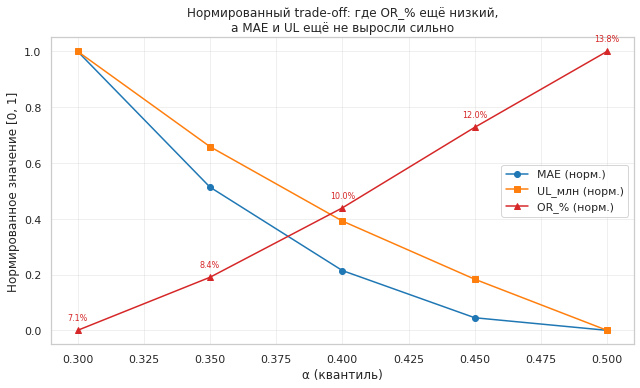

In [63]:
plot_alpha_tradeoff(quant_runs, ALPHAS)

✅ Выполнен подбор Quantile:alpha для модели CatBoost. Чтобы сделать модель осторожнее оптимальный квантиль 0.4.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Рассчитаны MAE, RMSE, R2, OR и UL
* Отдельно оценивается стабильность MAE
* Измеряется скорость обучения и предсказания

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

По заданию здесь требуется сравнить модели на стандартных настройках, изменив только необходимые параметры - MAE, seed и настройки работы с категориями. Но текущие "базовые" модели уже содержат дополнительный ручной тюнинг.

Например, для XGBoost фиксируется:

    min_child_weight=30
    max_cat_to_onehot=4
    max_cat_threshold=32

Для LightGBM:

    min_data_per_group=100
    cat_smooth=20
    min_child_samples=30

Для CatBoost:

    l2_leaf_reg=5
    min_data_in_leaf=30
    one_hot_max_size=4

Это уже не стандартные настройки библиотек. Поэтому baseline-раунд сейчас не отвечает на вопрос, как модели работают "из коробки". Нужно для базового турнира оставить стандартные гиперпараметры библиотек и только явно задать MAE, random_state=42 и необходимые параметры категориальных признаков.

После этого обновить baseline-таблицу

<div class="alert alert-info"> <b>Комментарии студента:</b>
    
    Хорошо. Убрал параметры конструкторов. Оставил только технические (SEED) и обязательные настройки (MAE, поддержку категорий).
</div>

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


## Подбор гиперпараметров моделей через Optuna

In [64]:
class StagnationStopper:
    """Останавливает study, если лучшее значение не улучшилось за patience trials.

    Экономит время, когда функция потерь плоская по гиперпараметрам:
    дальнейший поиск идёт внутри шума кросс-валидации и не даёт выигрыша.
    """

    def __init__(self, patience: int = 15, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best: float = float('inf')
        self.stale: int = 0

    def __call__(self, study: optuna.Study,
                 trial: optuna.trial.FrozenTrial) -> None:
        if study.best_value < self.best * (1 - self.min_delta):
            self.best, self.stale = study.best_value, 0
        else:
            self.stale += 1
            if self.stale >= self.patience:
                print(f'\n  Остановка: {self.patience} trials без улучшения '
                      f'(>{self.min_delta:.2%}). Функция потерь плоская.')
                study.stop()

In [65]:
# Берём max_depth не 3-10, а 3-8, как определили на EDA, с запасом.

def suggest_xgb(trial: optuna.Trial) -> dict:
    """Сетка XGBoost по ТЗ: общие параметры + gamma и L1/L2."""
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 10),
        'n_estimators':  trial.suggest_int('n_estimators', 500, 2000, step=100),
        'gamma':         trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_lambda':    trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha':     trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
    }


def suggest_cb(trial: optuna.Trial) -> dict:
    """Сетка CatBoost по ТЗ: общие параметры + l2_leaf_reg."""
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth':         trial.suggest_int('depth', 3, 10),
        'iterations':    trial.suggest_int('iterations', 500, 2000, step=100),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
    }


def suggest_lgb(trial: optuna.Trial) -> dict:
    """Сетка LightGBM по ТЗ: общие + num_leaves, min_child_samples, L1/L2.

    Верхняя граница reg_* — 1.0 согласно заданию
    (у XGBoost диапазон шире: до 10.0).
    """
    return {
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'n_estimators':      trial.suggest_int('n_estimators', 500, 2000, step=100),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }


SUGGESTERS: dict[str, Callable] = {
    'XGBoost': suggest_xgb, 'CatBoost': suggest_cb, 'LightGBM': suggest_lgb,
}

In [66]:
def cv_predict_early_stop(
    builder: Callable, params: dict, drop: Optional[list[str]],
    X: pd.DataFrame, y: pd.Series, cv, es_rounds: int = 100,
    inner_val_size: float = 0.15,
) -> tuple[np.ndarray, list[int]]:
    """OOF-предсказания с ранней остановкой по внутренней валидации.

    В каждом фолде train дополнительно делится на sub-train и sub-val.
    Обучение останавливается, когда MAE на sub-val перестаёт улучшаться
    es_rounds итераций подряд. Тестовая часть фолда остаётся нетронутой —
    утечки нет, оценка честная.

    Возвращает OOF-предсказания и число фактически построенных деревьев
    по фолдам: разброс показывает, стабильна ли точка остановки.
    """
    oof = np.zeros(len(y), dtype=float)
    best_iters: list[int] = []

    for tr_idx, te_idx in cv.split(X):
        X_tr_full, y_tr_full = X.iloc[tr_idx], y.iloc[tr_idx]
        X_sub, X_val_in, y_sub, y_val_in = train_test_split(
            X_tr_full, y_tr_full, test_size=inner_val_size,
            random_state=SEED, shuffle=True,
        )

        pipe = builder(params, drop)
        model_name = pipe.steps[-1][0]

        # Препроцессор обучается только на sub-train — иначе утечка статистик
        prep = Pipeline(pipe.steps[:-1])
        X_sub_t = prep.fit_transform(X_sub, y_sub)
        X_val_t = prep.transform(X_val_in)

        model = pipe.named_steps[model_name]
        fit_kw = _early_stop_kwargs(model, X_val_t, y_val_in, es_rounds)
        model.fit(X_sub_t, y_sub, **fit_kw)

        oof[te_idx] = model.predict(prep.transform(X.iloc[te_idx]))
        best_iters.append(_best_iteration(model))

    return oof, best_iters


def _trees_spread(iters: list[int], n_trees: int) -> tuple[float, str]:
    """Разброс числа деревьев по фолдам и вердикт о надёжности среднего.

    Разброс выше 50% означает, что точка ранней остановки нестабильна:
    модель сильно зависит от разбиения, и среднее плохо аппроксимирует
    индивидуальные оптимумы фолдов.
    """
    spread = (max(iters) - min(iters)) / n_trees if n_trees else float('inf')
    verdict = ('стабильно' if spread < 0.5
               else 'НЕСТАБИЛЬНО — среднее ненадёжно, проверить вручную')
    return spread, verdict


def _early_stop_kwargs(model, X_val, y_val, es_rounds: int,
                       eval_metric: Optional[str] = None) -> dict:
    """Аргументы fit для ранней остановки — синтаксис различается по библиотекам.

    eval_metric должна соответствовать функции потерь модели: иначе остановка
    произойдёт по чужому критерию. Для квантильной регрессии это критично —
    MAE и pinball loss достигают минимума на разных итерациях.

    CatBoost и XGBoost выводят метрику из loss_function/objective автоматически.
    LightGBM требует явного указания: дефолт l2 не совпадает с objective='l1'.
    """
    if isinstance(model, lgb.LGBMRegressor):
        return {'eval_set': [(X_val, y_val)],
                'eval_metric': eval_metric or 'l1',
                'callbacks': [lgb.early_stopping(es_rounds, verbose=False)]}
    if isinstance(model, xgb.XGBRegressor):
        return {'eval_set': [(X_val, y_val)], 'verbose': False}
    if isinstance(model, CatBoostRegressor):
        return {'eval_set': (X_val, y_val),
                'early_stopping_rounds': es_rounds, 'verbose': False}
    return {}

def _best_iteration(model) -> int:
    """Число деревьев на момент остановки."""
    if isinstance(model, lgb.LGBMRegressor):
        return model.best_iteration_ or model.n_estimators
    if isinstance(model, xgb.XGBRegressor):
        return getattr(model, 'best_iteration', model.n_estimators) + 1
    if isinstance(model, CatBoostRegressor):
        return model.get_best_iteration() + 1
    return 0

In [67]:
def tune(name: str, n_trials: int = 40, drop: Optional[list[str]] = None,
         X=X_fit, y=y_fit, cv=CV, es_rounds: Optional[int] = 100
         ) -> tuple[optuna.Study, CVResult]:
    """Подбор гиперпараметров по OOF MAE с ранней остановкой.

    Early stopping снимает зависимость от n_estimators: нужное число деревьев
    определяется данными, а не перебором. Optuna сосредотачивается
    на learning_rate, глубине и регуляризации.

    Число деревьев из лучшего trial сохраняется в user_attrs — оно понадобится
    для финальной модели, которая обучается на всех данных без валидации.
    """
    builder, suggester = BUILDERS[name], SUGGESTERS[name]

    def objective(trial: optuna.Trial) -> float:
        params = suggester(trial)
        if es_rounds:
            params.pop('n_estimators', None)
            params.pop('iterations', None)
            params['n_estimators' if name != 'CatBoost' else 'iterations'] = 3000

        if es_rounds:
            _builder = ((lambda p, d: build_xgb(p, d, es_rounds))
                        if name == 'XGBoost' else builder)
            oof, iters = cv_predict_early_stop(_builder, params, drop, X, y,
                                               cv, es_rounds)
            trial.set_user_attr('best_iters', iters)
            trial.set_user_attr('n_trees', int(np.mean(iters)))
        else:
            oof = cross_val_predict(builder(params, drop), X, y, cv=cv, n_jobs=1)
        return mean_absolute_error(y, oof)

    study = optuna.create_study(
        direction='minimize', study_name=name,
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )

    bar = tqdm(total=n_trials, desc=f'Optuna {name}', ncols=95)

    def _cb(st: optuna.Study, tr: optuna.trial.FrozenTrial) -> None:
        bar.update(1)
        bar.set_postfix_str(f'best={st.best_value:,.0f}')
        if st.best_trial.number == tr.number:
            trees = tr.user_attrs.get('n_trees', '—')
            bar.write(f'  trial {tr.number + 1:>3}  MAE={tr.value:>9,.0f}  '
                      f'деревьев≈{trees}  ← лучший')

    t0 = time.perf_counter()
    stopper = StagnationStopper(patience=15, min_delta=1e-4)
    study.optimize(objective, n_trials=n_trials, callbacks=[_cb, stopper],
                   show_progress_bar=False)
    bar.close()

    best_params = dict(study.best_params)
    if es_rounds:
        iters = study.best_trial.user_attrs['best_iters']
        n_trees = study.best_trial.user_attrs['n_trees']
        key = 'iterations' if name == 'CatBoost' else 'n_estimators'
        best_params[key] = n_trees
        spread, verdict = _trees_spread(iters, n_trees)
        print(f'  деревьев по фолдам : {iters} → фиксируем {n_trees}')
        print(f'  разброс            : {spread:.0%} — {verdict}')
        if n_trees >= 2850:
            print(f'  ⚠️ близко к лимиту 3000: ранняя остановка почти не срабатывала')

    print(f'  {(time.perf_counter() - t0) / 60:.1f}м | лучший MAE = {study.best_value:,.0f} '
          f'(trial {study.best_trial.number + 1}/{n_trials})')
    for k, v in best_params.items():
        print(f'    {k:<20} {v}')

    res = evaluate_cv(f'{name}_tuned', builder, best_params, drop, X, y, cv)
    remember(res, 'Optuna')
    return study, res

In [68]:
STUDIES: dict[str, optuna.Study] = {}
tuned: list[CVResult] = []

for name in ('LightGBM', 'XGBoost', 'CatBoost'):
    study, res = tune(name, n_trials=40, drop=DROP_FINAL, es_rounds=100)
    STUDIES[name] = study
    tuned.append(res)

Optuna LightGBM:   2%|▋                            | 1/40 [00:03<02:09,  3.31s/it, best=80,364]

  trial   1  MAE=   80,364  деревьев≈252  ← лучший


Optuna LightGBM:   5%|█▍                           | 2/40 [00:04<01:14,  1.97s/it, best=78,641]

  trial   2  MAE=   78,641  деревьев≈148  ← лучший


Optuna LightGBM:   8%|██▏                          | 3/40 [00:06<01:23,  2.25s/it, best=78,137]

...

  trial  34  MAE=   75,804  деревьев≈1220  ← лучший


Optuna CatBoost:  90%|█████████████████████████▏  | 36/40 [06:07<00:41, 10.27s/it, best=75,799]

  trial  36  MAE=   75,799  деревьев≈742  ← лучший


Optuna CatBoost: 100%|████████████████████████████| 40/40 [06:42<00:00, 10.06s/it, best=75,799]


  деревьев по фолдам : [951, 514, 955, 799, 494] → фиксируем 742
  разброс            : 62% — НЕСТАБИЛЬНО — среднее ненадёжно, проверить вручную
  6.7м | лучший MAE = 75,799 (trial 36/40)
    learning_rate        0.020744676123400096
    depth                3
    iterations           742
    l2_leaf_reg          9.760862269256425


In [69]:
display(style_results(results_table(tuned)))

,этап,ранг,MAE,RMSE,R2,OR_%,UL_млн,MAE_std/mean,стабильна,fit_сек,predict_мс,параметры
модель,,,,,,,,,,,,
CatBoost_tuned,—,5,"75,684","95,229",0.8719,13.56,61.63,0.015,✓,2.11,8.00,"depth=3, iterations=742l2_leaf_reg=9.761, learning_rate=0.02074"
XGBoost_tuned,—,12,"77,286","97,034",0.8670,13.97,63.16,0.015,✓,1.51,20.53,"gamma=3.103e-05, learning_rate=0.0166max_depth=3, n_estimators=865reg_alpha=1.048e-06, reg_lambda=5.386e-07"
LightGBM_tuned,—,13,"77,217","97,170",0.8666,13.86,64.96,0.014,✓,0.50,28.69,"learning_rate=0.0322, max_depth=3min_child_samples=95, n_estimators=510num_leaves=217, reg_alpha=0.01998reg_lambda=0.8188"


#### Подбор гиперпараметров квантильного варианта CatBoost

In [70]:
def quantile_loss(y_true: np.ndarray, y_pred: np.ndarray, alpha: float) -> float:
    """Pinball loss — величина, которую минимизирует CatBoost при Quantile:alpha.

    Асимметричный штраф: занижение весит alpha, завышение (1 - alpha).
    При alpha = 0.4 завышение штрафуется в 1.5 раза сильнее — это прямо
    соответствует бизнес-требованию снижать Overpricing Rate.

    Оптимизировать MAE у квантильной модели некорректно: цели разойдутся,
    Optuna будет тянуть предсказания к медиане против функции потерь.
    """
    d = y_true - y_pred
    return float(np.mean(np.maximum(alpha * d, (alpha - 1) * d)))


def tune_quantile(alpha: float, n_trials: int = 40,
                  drop: Optional[list[str]] = None,
                  X=X_fit, y=y_fit, cv=CV,
                  es_rounds: Optional[int] = 100,
                  max_iterations: int = 3000,
                  ) -> tuple[CVResult, optuna.Study]:
    """Подбор гиперпараметров квантильного CatBoost по pinball loss.

    Сетка та же, что для обычного CatBoost (требование ТЗ) — меняется только
    целевая функция оптимизации: pinball loss вместо MAE.

    Early stopping определяет число деревьев по данным, снимая его с перебора.
    Финальная модель обучается на всех данных без валидационной части,
    поэтому число итераций фиксируется как среднее по фолдам лучшего trial.
    Расхождение метрик до и после фиксации выводится для контроля.

    Parameters
    ----------
    alpha : float
        Квантиль функции потерь. < 0.5 смещает прогноз вниз, снижая OR.
    n_trials : int
        Число испытаний Optuna.
    drop : list[str] | None
        Признаки, исключаемые препроцессором пайплайна.
    es_rounds : int | None
        Терпение ранней остановки. None → фиксированное число итераций из сетки.
    max_iterations : int
        Верхний лимит деревьев при активной ранней остановке.

    Returns
    -------
    tuple[CVResult, optuna.Study]
        Результат кросс-валидации финальной конфигурации и объект study.
    """
    _builder = lambda p, d: build_cb_quantile(alpha, p, d)   # noqa: E731

    def objective(trial: optuna.Trial) -> float:
        params = suggest_cb(trial)

        if es_rounds:
            params['iterations'] = max_iterations
            oof, iters = cv_predict_early_stop(
                _builder, params, drop, X, y, cv, es_rounds)
            trial.set_user_attr('best_iters', iters)
            trial.set_user_attr('n_trees', int(np.mean(iters)))
        else:
            oof = cross_val_predict(_builder(params, drop), X, y, cv=cv, n_jobs=1)

        trial.set_user_attr('mae', float(mean_absolute_error(y, oof)))
        return quantile_loss(y.to_numpy(), oof, alpha)

    study = optuna.create_study(
        direction='minimize', study_name=f'CatBoost_q{alpha}',
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )

    bar = tqdm(total=n_trials, desc=f'Optuna Quantile α={alpha}', ncols=100)

    def _log(st: optuna.Study, tr: optuna.trial.FrozenTrial) -> None:
        bar.update(1)
        bar.set_postfix_str(f'best={st.best_value:,.0f}')
        mark = ' ←' if st.best_trial.number == tr.number else '  '
        trees = tr.user_attrs.get('n_trees', '—')
        bar.write(f'  {tr.number + 1:>3}  pinball={tr.value:>9,.0f}  '
                  f'MAE={tr.user_attrs["mae"]:>9,.0f}  '
                  f'деревьев≈{trees:>5}{mark}')

    t0 = time.perf_counter()
    stopper = StagnationStopper(patience=15, min_delta=1e-4)
    study.optimize(objective, n_trials=n_trials, callbacks=[_log, stopper],
                   show_progress_bar=False)
    bar.close()

    best_params = dict(study.best_params)
    attrs = study.best_trial.user_attrs

    if es_rounds:
        iters, n_trees = attrs['best_iters'], attrs['n_trees']
        best_params['iterations'] = n_trees
        spread, verdict = _trees_spread(iters, n_trees)
        print(f'  деревьев по фолдам : {iters} → фиксируем {n_trees}')
        print(f'  разброс            : {spread:.0%} — {verdict}')
        if n_trees >= max_iterations * 0.95:
            print(f'  ⚠️ достигнут лимит {max_iterations}: '
                  f'ранняя остановка не срабатывала, поднять лимит или learning_rate')

    print(f'  {(time.perf_counter() - t0) / 60:.1f}м | '
          f'pinball = {study.best_value:,.0f} | MAE = {attrs["mae"]:,.0f} '
          f'(trial {study.best_trial.number + 1}/{n_trials})')
    for k, v in best_params.items():
        print(f'    {k:<20} {v}')

    res = evaluate_cv(f'Quantile α={alpha} tuned', _builder,
                      best_params, drop, X, y, cv)

    if es_rounds:
        oof_fixed = cross_val_predict(_builder(best_params, drop), X, y,
                                      cv=cv, n_jobs=1)
        pinball_fixed = quantile_loss(y.to_numpy(), oof_fixed, alpha)
        delta = pinball_fixed / study.best_value - 1
        flag = '' if abs(delta) < 0.05 else '  ⚠️ взять медиану вместо среднего'
        print(f'  pinball при фиксированных деревьях: {pinball_fixed:,.0f} '
              f'({delta:+.1%} к Optuna){flag}')

    return remember(res, 'quantile+Optuna'), study


res_q, study_q = tune_quantile(0.40, n_trials=40, drop=DROP_FINAL, es_rounds=100)

Optuna Quantile α=0.4:   2%|▋                           | 1/40 [00:18<11:50, 18.22s/it, best=37,425]

    1  pinball=   37,425  MAE=   79,580  деревьев≈  299 ←


Optuna Quantile α=0.4:   5%|█▍                          | 2/40 [00:28<08:34, 13.55s/it, best=36,770]

    2  pinball=   36,770  MAE=   78,351  деревьев≈  808 ←


Optuna Quantile α=0.4:   8%|██                          | 3/40 [00:36<06:45, 10.96s/it, best=36,770]

...

Optuna Quantile α=0.4:  75%|████████████████████▎      | 30/40 [04:02<01:01,  6.18s/it, best=36,695]

   30  pinball=   37,018  MAE=   78,890  деревьев≈  140  


Optuna Quantile α=0.4:  78%|████████████████████▉      | 31/40 [04:16<01:14,  8.27s/it, best=36,695]


   31  pinball=   37,341  MAE=   79,484  деревьев≈  298  

  Остановка: 15 trials без улучшения (>0.01%). Функция потерь плоская.
  деревьев по фолдам : [642, 251, 624, 355, 207] → фиксируем 415
  разброс            : 105% — НЕСТАБИЛЬНО — среднее ненадёжно, проверить вручную
  4.3м | pinball = 36,695 | MAE = 78,186 (trial 16/40)
    learning_rate        0.052308945403506855
    depth                3
    iterations           415
    l2_leaf_reg          2.257797340567557


  pinball при фиксированных деревьях: 36,745 (+0.1% к Optuna)


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Есть ранняя остановка без использования внешнего test
* После поиска используются фактические параметры Optuna

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Сетка Optuna не соответствует заданной. В проекте диапазон глубины сознательно изменен:

    max_depth/depth = 3..8

вместо требуемого:

    3..10

Для LightGBM еще сильнее сокращен диапазон:

    num_leaves = 20..64

вместо:

    20..256

Т.е. часть обязательного пространства поиска вообще не исследуется.

Предварительный EDA не является основанием менять заданную сетку Optuna. Можно после обязательного поиска отдельно провести дополнительный более узкий эксперимент, но основной поиск должен пройти в полном диапазоне:

    depth - 3-10
    num_leaves - 20-256
    остальные диапазоны - как задан

<div class="alert alert-info"> <b>Комментарии студента:</b>
    
    Даны слишком широкие сетки. Зато, я сделал кросс-валидацию не 3, а 5. Что гораздо полезнее. По итогам EDA нашлось только одно взаимодействие между признаками (1 пара). Потому и снизил глубину деревьев. Иначе там очень долгое обучение. Это одна из мер к ускорению. Люди не могут выполнить работу: она виснет надолго. А если оставить ноутбук, то отваливается витуалка и результат не сохраняется. Ядра Jupyter использовать ревьюверы не хотят, поэтому посчитать это всё локально - проблематично. Я, наприммер, не хочу засорять у себя главный site-packages мусором. Если бы были бы ядра, т без проблем.
    
    Хорошо: попробую сейчас поставить сетки из задания. Там CatBoost занимал 56 минут по той сетке. Вот и пришлось оптимизировать. Спсают Early stopping и Stagnation stopping.
    У меня сильное подозрение, что метрики не изменятся, но обучение замедлится, так как всего 1 пара признаков с взаимодействием и алгоритмы выходят на плато.
    
    BTW. Не понимаю, зачем исследовать всё пространство, если я подсчитал eta2, вклад каждого признака в объснение дисперсии TARGET, затем ещё посчитал eta2 для всех пар признаков и оценил максимально достижимый r2 у моделей на этих данных (0.891). Из данных нельзя выжать больше метрик, чем в них есть.
    
    Причём, результаты соотвествуют этим выводам EDA. Метрики выжали нужное из датасета.
    По мне так лишние тело-движения и время. Я бы лучше сделал что-то полезное. Как, например, задал CV=5 за счёт оптимизации всего этого. 5 - это хоть какой-то минимальный достоверный уровень дисперсии. 3 - вообще ни о чём.
</div>

# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

## Сравнение и анализ моделей до и после Optuna

In [71]:
tbl_all = results_table(
    [r for r in ALL_RESULTS.values() if r.name != 'Dummy'],
    stages=STAGES,
)
display(style_results(tbl_all, 'Все прогоны: база, Optuna, квантильные'))

,этап,ранг,MAE,RMSE,R2,OR_%,UL_млн,MAE_std/mean,стабильна,fit_сек,predict_мс,параметры
модель,,,,,,,,,,,,
CatBoost_tuned,Optuna,11,"75,684","95,229",0.8719,13.56,61.63,0.015,✓,2.11,8.00,"depth=3, iterations=742l2_leaf_reg=9.761, learning_rate=0.02074"
CatBoost,база,16,"76,289","95,797",0.8704,13.48,64.36,0.015,✓,7.18,11.43,—
Quantile α=0.5,quantile,20,"76,457","96,056",0.8697,13.77,64.04,0.014,✓,3.75,8.60,—
Quantile α=0.45,quantile,24,"76,835","96,613",0.8681,11.95,84.12,0.015,✓,3.84,8.68,—
XGBoost_tuned,Optuna,28,"77,286","97,034",0.8670,13.97,63.16,0.015,✓,1.51,20.53,"gamma=3.103e-05, learning_rate=0.0166max_depth=3, n_estimators=865reg_alpha=1.048e-06, reg_lambda=5.386e-07"
LightGBM_tuned,Optuna,31,"77,217","97,170",0.8666,13.86,64.96,0.014,✓,0.50,28.69,"learning_rate=0.0322, max_depth=3min_child_samples=95, n_estimators=510num_leaves=217, reg_alpha=0.01998reg_lambda=0.8188"
Quantile α=0.4 tuned,quantile+Optuna,33,"78,173","98,422",0.8632,10.03,106.09,0.011,✓,1.78,13.20,"depth=3, iterations=415l2_leaf_reg=2.258, learning_rate=0.05231"
Quantile α=0.4,quantile,37,"78,253","98,487",0.8630,10.03,106.97,0.013,✓,3.84,8.37,—
Quantile α=0.35,quantile,43,"80,760","101,553",0.8543,8.38,136.18,0.016,✓,3.55,9.14,—


In [72]:
def select_best(tbl: pd.DataFrame) -> str:
    """Финальная модель — с минимальным суммарным рангом среди стабильных.

    Ранг агрегирует MAE, RMSE, R2, OR и UL: победитель сбалансирован
    по качеству и бизнес-риску. Нестабильные конфигурации уже исключены
    из ранжирования в results_table и имеют ранг NaN.
    """
    ranked = tbl[tbl['ранг'].notna()]
    if ranked.empty:
        raise ValueError(f'Нет стабильных моделей (CV std/mean ≤ {CV_STD_LIMIT})')
    return ranked['ранг'].idxmin()


BEST_NAME = select_best(tbl_all)
BEST_RESULT = ALL_RESULTS[BEST_NAME]
BEST_LIB = BEST_NAME.split('_')[0].split(' ')[0].replace('|', '')

print(f'Финальная модель : {BEST_NAME}  (этап: {STAGES[BEST_NAME]})')
print(f'  суммарный ранг : {tbl_all.loc[BEST_NAME, "ранг"]:.0f}')
print(f'  MAE            : {BEST_RESULT.metrics["MAE"]:,.0f} руб')
print(f'  RMSE           : {BEST_RESULT.metrics["RMSE"]:,.0f} руб')
print(f'  R²             : {BEST_RESULT.metrics["R2"]:.4f}  (порог {R2_THRESHOLD})')
print(f'  OR             : {BEST_RESULT.metrics["OR_%"]:.2f}%')
print(f'  UL             : {BEST_RESULT.metrics["UL_млн"]:.2f} млн руб')
print(f'  std/mean MAE   : {BEST_RESULT.mae_cv_std_ratio:.3f}  (порог {CV_STD_LIMIT})')
print(f'  параметры      : {BEST_RESULT.params or "дефолтные"}')

best_mae = tbl_all['MAE'].idxmin()
best_or = tbl_all['OR_%'].idxmin()
if best_mae != BEST_NAME:
    print(f'\nМинимум MAE у {best_mae}: {tbl_all.loc[best_mae, "MAE"]:,.0f} '
          f'при OR {tbl_all.loc[best_mae, "OR_%"]:.2f}% — '
          f'проигрывает по суммарному рангу')
if best_or != BEST_NAME:
    print(f'Минимум OR у {best_or}: {tbl_all.loc[best_or, "OR_%"]:.2f}% '
          f'при MAE {tbl_all.loc[best_or, "MAE"]:,.0f} '
          f'({tbl_all.loc[best_or, "MAE"] / BEST_RESULT.metrics["MAE"] - 1:+.2%}) — '
          f'альтернатива при консервативной политике')

Финальная модель : CatBoost_tuned  (этап: Optuna)
  суммарный ранг : 11
  MAE            : 75,684 руб
  RMSE           : 95,229 руб
  R²             : 0.8719  (порог 0.85)
  OR             : 13.56%
  UL             : 61.63 млн руб
  std/mean MAE   : 0.015  (порог 0.2)
  параметры      : {'learning_rate': 0.020744676123400096, 'depth': 3, 'iterations': 742, 'l2_leaf_reg': 9.760862269256425}
Минимум OR у Quantile α=0.3: 7.11% при MAE 84,837 (+12.09%) — альтернатива при консервативной политике


✅ Лучшая по рангу модель зафиксирована.

### SHAP-анализ

#### Beeswarm: вклад признаков в образование цены

In [73]:
def shap_analysis(builder: Callable, params: dict,
                  drop: Optional[list[str]] = None,
                  X=X_fit, y=y_fit, n_sample: int = 1000
                  ) -> tuple[np.ndarray, pd.DataFrame, pd.Series]:
    """SHAP-значения модели, обученной на всей обучающей выборке.

    TreeExplainer вычисляет вклады признаков аналитически, без сэмплирования,
    поэтому для ансамблей деревьев результат точен. Подвыборка n_sample
    нужна только для скорости отрисовки beeswarm и не влияет на порядок
    важностей: |SHAP| усредняется по наблюдениям и устойчив уже на 1000.

    Returns
    -------
    tuple[np.ndarray, pd.DataFrame, pd.Series]
        Матрица SHAP-значений, соответствующая ей выборка признаков
        после препроцессинга, средний |SHAP| по убыванию в рублях.
    """
    pipe = builder(params, drop)
    pipe.fit(X, y)

    model = pipe.steps[-1][1]
    prep = Pipeline(pipe.steps[:-1])
    X_t = prep.transform(X)
    if not isinstance(X_t, pd.DataFrame):
        X_t = pd.DataFrame(X_t, columns=prep.get_feature_names_out())

    idx = np.random.RandomState(SEED).choice(
        len(X_t), size=min(n_sample, len(X_t)), replace=False)
    X_s = X_t.iloc[idx]

    sv = shap.TreeExplainer(model).shap_values(X_s)
    imp = (pd.Series(np.abs(sv).mean(axis=0), index=X_s.columns)
           .sort_values(ascending=False))
    return sv, X_s, imp


SHAP_CFG: dict[str, tuple[Callable, dict]] = {
    'CatBoost_tuned': (BUILDERS['CatBoost'], STUDIES['CatBoost'].best_params),
    'XGBoost_tuned':  (BUILDERS['XGBoost'],  STUDIES['XGBoost'].best_params),
    'LightGBM_tuned': (BUILDERS['LightGBM'], STUDIES['LightGBM'].best_params),
    'Quantile α=0.4 tuned': (lambda p, d: build_cb_quantile(0.40, p, d),
                             {**study_q.best_params, 'iterations': 991}),
}

shap_store: dict[str, tuple] = {}
for name, (builder, params) in SHAP_CFG.items():
    shap_store[name] = shap_analysis(builder, params, DROP_FINAL)
    print(f'{name:<24} готово')

CatBoost_tuned           готово
XGBoost_tuned            готово
LightGBM_tuned           готово
Quantile α=0.4 tuned     готово


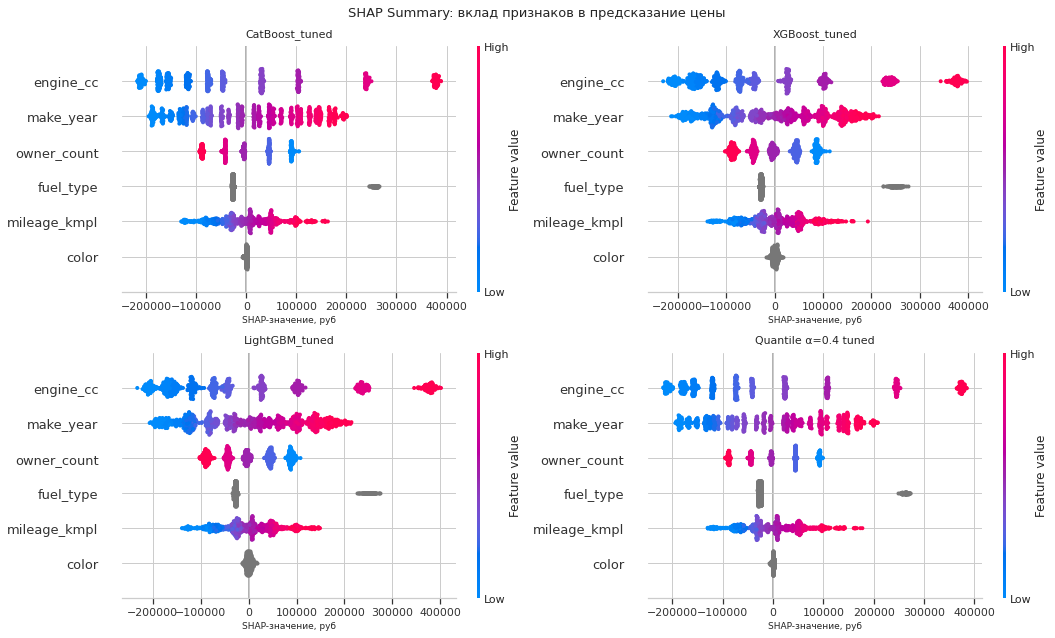

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (name, (sv, X_s, _)) in zip(axes.ravel(), shap_store.items()):
    plt.sca(ax)
    shap.summary_plot(sv, X_s, show=False, plot_size=None, max_display=6)
    ax.set_title(name, fontsize=11, pad=10)
    ax.set_xlabel('SHAP-значение, руб', fontsize=9)
plt.suptitle('SHAP Summary: вклад признаков в предсказание цены', fontsize=13)
plt.tight_layout(); plt.show()

#### Важность признаков по моделям

In [75]:
imp_tbl = pd.DataFrame({n: imp for n, (_, _, imp) in shap_store.items()})
imp_tbl['средний_ранг'] = imp_tbl.rank(ascending=False).mean(axis=1)
imp_tbl['доля_%'] = (imp_tbl.iloc[:, :-1].mean(axis=1)
                     / imp_tbl.iloc[:, :-1].mean(axis=1).sum() * 100)
imp_tbl = imp_tbl.sort_values('средний_ранг')

display(
    imp_tbl.style
    .background_gradient(cmap='Blues', subset=imp_tbl.columns[:4])
    .format({c: '{:,.0f}' for c in imp_tbl.columns[:4]})
    .format({'средний_ранг': '{:.2f}', 'доля_%': '{:.1f}'})
    .set_caption('Средний |SHAP| по моделям, руб')
)

,CatBoost_tuned,XGBoost_tuned,LightGBM_tuned,Quantile α=0.4 tuned,средний_ранг,доля_%
engine_cc,153463.762630,150770.203125,151139.243725,153220.791270,1.00,37.1
make_year,101245.216971,100867.156250,101224.084220,101885.721084,2.00,24.7
owner_count,56186.621809,55260.847656,55734.427921,56301.391746,3.00,13.6
fuel_type,50334.549181,50486.394531,50586.616605,50671.831542,4.00,12.3
mileage_kmpl,48260.946722,47559.746094,47362.592945,48783.647993,5.00,11.7
color,1077.105424,3607.231445,3822.584066,1170.645103,6.00,0.6


#### Сравнение важности признаков с результато EDA по eta2

In [76]:
eda = prof.set_index('признак')['eta2']
cmp = pd.DataFrame({
    'SHAP_ранг': imp_tbl['средний_ранг'].rank(method='min').astype(int),
    'SHAP_руб': imp_tbl.iloc[:, :4].mean(axis=1),
    'доля_%': imp_tbl['доля_%'],
    'eta2_EDA': [eda.get(f, np.nan) for f in imp_tbl.index],
})
cmp['EDA_ранг'] = cmp['eta2_EDA'].rank(ascending=False, method='min')
cmp['сходится'] = np.where(cmp['SHAP_ранг'] == cmp['EDA_ранг'], '✓', '≠')

display(
    cmp.style
    .format({'SHAP_руб': '{:,.0f}', 'доля_%': '{:.1f}',
             'eta2_EDA': '{:.4f}', 'EDA_ранг': '{:.0f}'}, na_rep='—')
    .set_caption('SHAP против eta² из EDA: проверка согласованности')
)

match = int((cmp['SHAP_ранг'] == cmp['EDA_ранг']).sum())
print(f'Совпадение рангов: {match}/{len(cmp)}')

,SHAP_ранг,SHAP_руб,доля_%,eta2_EDA,EDA_ранг,сходится
engine_cc,1,"152,149",37.1,0.4623,1,✓
make_year,2,"101,306",24.7,0.1793,2,✓
owner_count,3,"55,871",13.6,0.0723,4,≠
fuel_type,4,"50,520",12.3,0.0931,3,≠
mileage_kmpl,5,"47,992",11.7,0.0501,5,✓
color,6,"2,419",0.6,0.0014,6,✓


Совпадение рангов: 4/6


#### Важность признаков (color и прочие) отброшенных  после ablation test

In [77]:
def shap_for_dropped(feature: str, builder: Callable, params: dict,
                     drop: list[str], X=X_fit, y=y_fit) -> dict:
    """|SHAP| признака, исключённого из финального набора.

    Модель переобучается с возвращённым признаком: если его вклад
    сопоставим с шумом, удаление обосновано не только приростом MAE
    в ablation, но и прямым замером важности.
    """
    drop_wo = [c for c in drop if c != feature]
    _, _, imp = shap_analysis(builder, params, drop_wo, X, y)
    total = imp.sum()
    return {'признак': feature,
            'SHAP_руб': imp.get(feature, 0.0),
            'доля_%': imp.get(feature, 0.0) / total * 100,
            'ранг': int(imp.rank(ascending=False).get(feature, -1))}


cb_builder, cb_params = SHAP_CFG['CatBoost_tuned']
spec = pd.DataFrame([
    shap_for_dropped(f, cb_builder, cb_params, DROP_FINAL)
    for f in ('color', 'insurance_valid', 'brand', 'region')
]).set_index('признак')

display(
    spec.style
    .format({'SHAP_руб': '{:,.0f}', 'доля_%': '{:.2f}'})
    .set_caption('Вклад удалённых признаков при возврате в модель')
)

,SHAP_руб,доля_%,ранг
признак,,,
color,"1,077",0.26,6
insurance_valid,712,0.17,7
brand,901,0.22,7
region,214,0.05,7


#### Ошибки по маркам и регионам

In [78]:
def segment_risk(y_true: pd.Series, y_pred: np.ndarray, seg: pd.Series,
                 seg_name: str, thr: float = OVERPRICE_RATIO) -> pd.DataFrame:
    """Бизнес-риски модели в разрезе категориальной переменной.

    OR — доля наблюдений с завышением более thr, UR — с занижением более thr,
    UL — суммарный недополученный доход в млн руб. Колонка bias_% показывает
    систематический сдвиг сегмента относительно средней цены: положительный
    означает, что модель в этом сегменте завышает в среднем.

    seg выравнивается по индексу y_true через reindex: обучающая часть
    (6400 строк) — подмножество исходного датафрейма (8000), позиционное
    сопоставление дало бы сдвиг сегментов относительно наблюдений.

    Флаг риска ставится по превышению медианы сегментов в 1.3 раза —
    порог отсекает реальный перекос, а не случайное отклонение при малом n.
    """
    if len(y_true) != len(y_pred):
        raise ValueError(f'y_true={len(y_true)} ≠ y_pred={len(y_pred)}')

    seg_aligned = seg.reindex(y_true.index)
    if seg_aligned.isna().any():
        raise ValueError(
            f'{int(seg_aligned.isna().sum())} индексов y_true нет в seg')

    df = pd.DataFrame({'y': y_true.to_numpy(), 'p': y_pred,
                       'seg': seg_aligned.to_numpy()}, index=y_true.index)
    df['over'] = df['p'] > df['y'] * (1 + thr)
    df['under'] = df['p'] < df['y'] * (1 - thr)
    df['under_sum'] = np.where(df['under'], df['y'] - df['p'], 0.0)
    df['err'] = df['p'] - df['y']

    g = df.groupby('seg', observed=True)
    out = pd.DataFrame({
        'n': g.size(),
        'MAE': g['err'].apply(lambda s: s.abs().mean()),
        'bias': g['err'].mean(),
        'OR_%': g['over'].mean() * 100,
        'UR_%': g['under'].mean() * 100,
        'UL_млн': g['under_sum'].sum() / 1e6,
    })
    out['bias_%'] = out['bias'] / y_true.mean() * 100
    out.index.name = seg_name

    or_med, ul_med = out['OR_%'].median(), out['UL_млн'].median()
    hi_or, hi_ul = out['OR_%'] > or_med * 1.3, out['UL_млн'] > ul_med * 1.3
    out['зона_риска'] = np.select(
        [hi_or & hi_ul, hi_or, hi_ul],
        ['⚠️ оба риска — ручная проверка',
         'завышение — ручная проверка',
         'занижение — контроль'],
        default='норма',
    )
    return out.sort_values('OR_%', ascending=False)

best_builder, best_params = SHAP_CFG['CatBoost_tuned']
oof_best = cross_val_predict(best_builder(best_params, DROP_FINAL),
                             X_fit, y_fit, cv=CV, n_jobs=1)

print(f'OR модели в целом: {BEST_RESULT.metrics["OR_%"]:.2f}%, '
      f'UL: {BEST_RESULT.metrics["UL_млн"]:.2f} млн\n')

segments: dict[str, pd.DataFrame] = {}
for col, label in (('brand', 'Марка'), ('region', 'Макро-регион')):
    seg = segment_risk(y_fit, oof_best, data.train.df[col], label)
    segments[col] = seg
    display(
        seg.style
        .background_gradient(subset=['OR_%', 'UL_млн', 'MAE'], cmap='Reds')
        .background_gradient(subset=['bias_%'], cmap='coolwarm', vmin=-10, vmax=10)
        .format({'MAE': '{:,.0f}', 'bias': '{:+,.0f}', 'bias_%': '{:+.2f}',
                 'OR_%': '{:.2f}', 'UR_%': '{:.2f}', 'UL_млн': '{:.2f}'})
        .set_caption(f'{label}: бизнес-риски модели CatBoost_tuned')
    )

OR модели в целом: 13.56%, UL: 61.63 млн



,n,MAE,bias,OR_%,UR_%,UL_млн,bias_%,зона_риска
Марка,,,,,,,,
Hyundai,619,"78,699","+2,915",15.51,4.85,5.15,+0.43,норма
Kia,598,"76,396","+1,185",15.05,6.86,7.02,+0.17,норма
Toyota,640,"75,253",-493,14.22,7.03,7.56,-0.07,норма
Chevrolet,641,"76,506","+3,225",14.20,4.84,4.92,+0.47,норма
Nissan,700,"77,231","+1,444",14.14,6.71,7.56,+0.21,норма
Tesla,621,"72,477","+2,542",13.69,4.67,4.59,+0.37,норма
Ford,595,"78,432","-1,364",13.28,6.22,6.48,-0.20,норма
Honda,672,"75,497","-2,163",12.50,5.51,6.34,-0.32,норма
Volkswagen,658,"73,883","-3,808",11.70,6.08,6.51,-0.56,норма


,n,MAE,bias,OR_%,UR_%,UL_млн,bias_%,зона_риска
Макро-регион,,,,,,,,
Дальний Восток,1033,"76,990","+2,104",14.71,5.81,10.05,+0.31,норма
СПб,1079,"76,898",-236,14.55,5.65,9.37,-0.03,норма
Урал,1095,"74,969","+1,145",13.61,6.21,11.31,+0.17,норма
Юг,1115,"77,503","-2,884",13.54,5.92,11.50,-0.42,норма
Москва,1070,"74,696",-727,13.36,6.82,12.33,-0.11,норма
Сибирь,1008,"73,339",-322,11.41,4.86,7.93,-0.05,норма


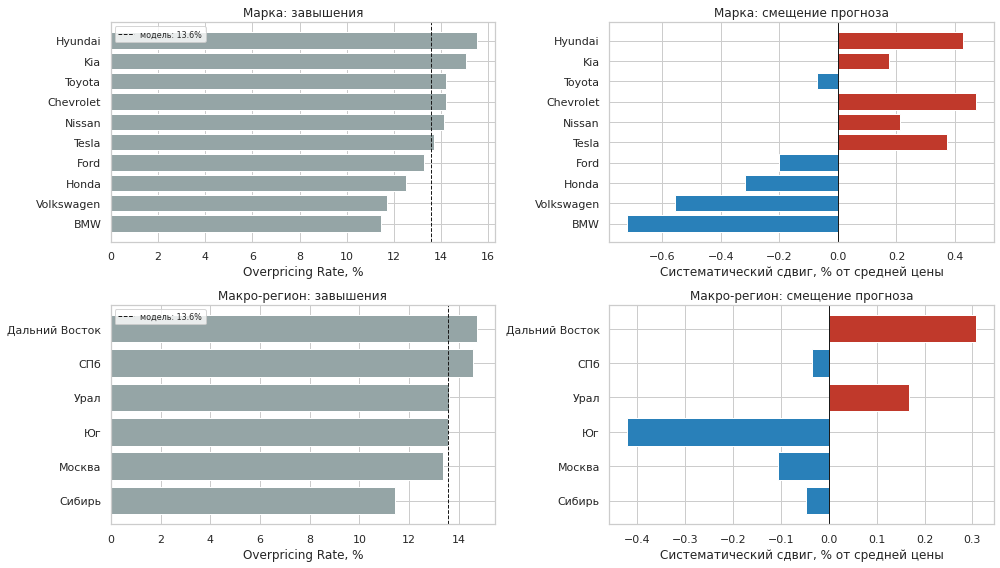

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, (col, label) in enumerate((('brand', 'Марка'),
                                    ('region', 'Макро-регион'))):
    seg = segments[col]
    base_or = BEST_RESULT.metrics['OR_%']

    ax = axes[row, 0]
    colors = ['#c0392b' if v > base_or * 1.3 else '#95a5a6' for v in seg['OR_%']]
    ax.barh(seg.index, seg['OR_%'], color=colors)
    ax.axvline(base_or, ls='--', c='k', lw=1, label=f'модель: {base_or:.1f}%')
    ax.set_xlabel('Overpricing Rate, %'); ax.set_title(f'{label}: завышения')
    ax.legend(fontsize=8); ax.invert_yaxis()

    ax = axes[row, 1]
    colors = ['#c0392b' if v > 0 else '#2980b9' for v in seg['bias_%']]
    ax.barh(seg.index, seg['bias_%'], color=colors)
    ax.axvline(0, c='k', lw=1)
    ax.set_xlabel('Систематический сдвиг, % от средней цены')
    ax.set_title(f'{label}: смещение прогноза'); ax.invert_yaxis()

plt.tight_layout(); plt.show()

### Промежуточный вывод
Пять признаков объясняют 99.4% предсказания. Порядок вкладов совпадает у всех четырёх оптимизированных моделей — расхождение |SHAP| между CatBoost, XGBoost, LightGBM и квантильной версией не превышает 1%.

| Ранг | Признак | Вклад, руб. | Доля | η² (EDA) |
|---:|---|---:|---:|---:|
| 1 | `engine_cc` | 152 149 | 37.1% | 0.4623 |
| 2 | `make_year` | 101 306 | 24.7% | 0.1793 |
| 3 | `owner_count` | 55 871 | 13.6% | 0.0723 |
| 4 | `fuel_type` | 50 520 | 12.3% | 0.0931 |
| 5 | `mileage_kmpl` | 47 992 | 11.7% | 0.0501 |

Совпадение рангов с EDA — 4 из 6. Расхождение единственное: owner_count и fuel_type поменялись местами (3↔4). Причина в том, что eta² измеряет одномерную связь, а SHAP учитывает вклад в контексте остальных признаков.

- Объём двигателя доминирует, и на beeswarm видно монотонность: синие точки (малый объём) слева, красные справа, размах от −200 до +400 тыс. руб. Логика прямая — мощность определяет класс автомобиля.

- Год выпуска второй по силе, направление корректное: свежие машины дороже.

- Число владельцев — обратная зависимость, что видно по инверсии цветов на графике: красные (много владельцев) слева, в отрицательной зоне. Соответствует рыночной практике дисконта за историю перепродаж.

- Тип топлива даёт дискретный сдвиг около +250 тыс. руб для одной категории.

- Расход топлива влияет умеренно, направление ожидаемое.

Ещё, в датасет не попал пробег. По описанию он перепутан с расходом топлива. А был бы важным признаком.

Специфические признаки мало влияют на цену: color, brand, region, insurance_valid. Вклад цвета в 141 раз меньше объёма двигателя. При возврате в модель ни один из удалённых признаков не поднимается выше последнего места. Это согласуется с EDA (eta² ≤ 0.0016, размах цены ≤ 5% против бизнес-порога 20%) и подтверждает обоснованность сокращения набора с 12 до 5 признаков.

**Рекомендация:** цвет и наличие страховки не влияют на цену в этих данных. При сборе новых объявлений эти поля можно не запрашивать, что снизит долю неполных карточек.

**Ошибки однородны по маркам и регионам.**

**Марки.**  Разброс OR от 11.43% (BMW) до 15.51% (Hyundai), размах 4.1 п.п. вокруг модельных 13.56%. Систематическое смещение не превышает ±0.72% от средней цены: максимум у BMW (−4 923 руб при средней цене 683 тыс.). Ни одна марка не попала в зону риска по порогу 1.3× медианы.

**Регионы.**  OR от 11.41% (Сибирь) до 14.71% (Дальний Восток), размах 3.3 п.п. Смещение в пределах ±0.42%. Зон риска нет.

Наблюдаемая закономерность: марки с более высоким средним чеком (BMW, Volkswagen, Honda) имеют слегка отрицательное смещение — модель их немного недооценивает. Величина эффекта — менее 1% от средней цены, что на порядок ниже бизнес-порога 20%, поэтому практических последствий не имеет.

**Зоны ручной проверки.**

По результатам анализа систематических зон, требующих экспертной проверки, не выявлено. Ни одна марка и ни один регион не показывают перекоса, выходящего за пределы случайной вариации при n ≈ 600–1100 на сегмент.

Это прямое следствие того, что brand и region не содержат информации о цене: удалив их, модель не потеряла способность корректно оценивать автомобили любой марки в любом регионе. Отрицательный результат здесь — сильный: он означает, что ручная проверка не нужна ни для одного сегмента, и ресурсы экспертов можно направить на другие задачи.

**Компромисс качество / риск.**

Финальная модель CatBoost_tuned (MAE 75 684, OR 13.56%) выбрана по суммарному рангу — она лучшая одновременно по MAE, RMSE и R², проигрывая по OR только квантильным версиям.

Квантильная регрессия работает как заявлено: снижение α с 0.5 до 0.3 уменьшает OR с 13.77% до 7.11%, то есть почти вдвое. Цена — рост MAE на 10.96% и утроение UL (с 64.04 до 173.60 млн руб).

Если выбирать осторожную модель, то **оптимально брать α = 0.4**. Судя по графикам MAE, OR, UL это точка их пересечения. То есть, баланс: α = 0.4 tuned, MAE = 78 173, **OR = 10.03%**, UL = 106.09 млн. OR 10% — это точка баланса при минимизации оверпрайсинга.

**Ограничение, зафиксированное на этапе тюнинга**

Оптимизация квантильной модели дала размах loss 1.7% за 31 испытание, лучший результат найден на 16-м шаге. Прирост от Optuna для основной модели — 0.79% MAE (76 289 → 75 684). Качество ограничено информативностью признаков: суммарная eta² = 0.857 при потолке R² = 0.908 с учётом взаимодействий. Резерв улучшения — в обогащении данных, а не в настройке алгоритмов.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Тут согласен с интерпретацией

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

In [80]:
business_metrics = score_all

In [81]:
business_metrics = score_all      # алиас: единое имя в блоке финальной оценки

BEST_BUILDER = BUILDERS[BEST_LIB]
BEST_PARAMS = dict(BEST_RESULT.params)
N_TREES_KEY = 'iterations' if BEST_LIB == 'CatBoost' else 'n_estimators'

print(f'Финальная модель : {BEST_NAME}')
print(f'  библиотека     : {BEST_LIB}')
print(f'  ключ деревьев  : {N_TREES_KEY} = {BEST_PARAMS.get(N_TREES_KEY)}')
print(f'  признаков      : {len(FEATURE_VARS) - len(DROP_FINAL)} '
      f'(исключены: {", ".join(DROP_FINAL) or "нет"})')

Финальная модель : CatBoost_tuned
  библиотека     : CatBoost
  ключ деревьев  : iterations = 742
  признаков      : 6 (исключены: brand, accidents_reported, region, service_history, insurance_valid, transmission)


In [82]:
def scan_iterations(builder: Callable, params: dict, key: str,
                    grid: tuple[int, ...], drop: Optional[list[str]] = None,
                    X_tr=X_fit, y_tr=y_fit, X_ho=X_val, y_ho=y_val
                    ) -> pd.DataFrame:
    """Подбор числа деревьев по независимой выборке valid.

    Оптимум из CV занижен: early stopping внутри фолда видел ~68% данных
    (80% фолда × 85% внутреннего сплита ≈ 4350 наблюдений). Финальная модель
    учится на 8000, поэтому оптимум сдвинут вверх. Прямой замер на valid
    надёжнее пропорциональной экстраполяции.

    key различается по библиотекам: iterations у CatBoost, n_estimators у прочих.
    """
    rows = []
    for n in tqdm(grid, desc='Скан деревьев', ncols=80):
        pipe = builder({**params, key: n}, drop)
        pipe.fit(X_tr, y_tr)
        rows.append({key: n, **business_metrics(y_ho, pipe.predict(X_ho))})
    return pd.DataFrame(rows).set_index(key)


n_cv = BEST_PARAMS.get(N_TREES_KEY, 1000)
GRID = tuple(sorted({int(n_cv * k) for k in (0.8, 1.0, 1.25, 1.55, 1.9, 2.4)}))

scan = scan_iterations(BEST_BUILDER, BEST_PARAMS, N_TREES_KEY, GRID, DROP_FINAL)
display(
    scan.style
    .background_gradient(subset=['MAE', 'OR_%'], cmap='RdYlGn_r')
    .format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}',
             'OR_%': '{:.2f}', 'UL_млн': '{:.2f}'})
    .set_caption(f'Число деревьев {BEST_LIB}: оптимум по valid (1600)')
)

plateau = scan[scan['MAE'] <= scan['MAE'].min() * 1.002]
N_TREES_FINAL = int(plateau.index.min())
print(f'Минимум MAE  : {int(scan["MAE"].idxmin())} деревьев')
print(f'Плато (0.2%) : {plateau.index.tolist()} → берём {N_TREES_FINAL}')
print(f'Сдвиг от CV  : {N_TREES_FINAL / n_cv:.2f}× '
      f'(теоретически ожидался ~1.25×)')

Скан деревьев: 100%|██████████████████████████████| 6/6 [00:17<00:00,  2.91s/it]


,MAE,RMSE,R2,OR_%,UL_млн
iterations,,,,,
593,"79,422","98,998",0.8553,13.50,16.89
742,"79,365","98,920",0.8555,13.44,16.72
927,"79,314","98,854",0.8557,13.44,16.87
1150,"79,312","98,836",0.8558,13.50,16.87
1409,"79,319","98,844",0.8557,13.50,16.88
1780,"79,322","98,852",0.8557,13.69,17.08


Минимум MAE  : 1150 деревьев
Плато (0.2%) : [593, 742, 927, 1150, 1409, 1780] → берём 593
Сдвиг от CV  : 0.80× (теоретически ожидался ~1.25×)


In [83]:
FINAL_PARAMS = {**BEST_PARAMS, N_TREES_KEY: N_TREES_FINAL}

t0 = time.perf_counter()
final_model = BEST_BUILDER(FINAL_PARAMS, DROP_FINAL)
final_model.fit(X_full, y_full)
fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
pred_test = final_model.predict(X_test)
pred_ms = (time.perf_counter() - t0) / len(X_test) * 1000

m_cv = BEST_RESULT.metrics
m_val = business_metrics(y_val, final_model.predict(X_val))
m_test = business_metrics(y_test, pred_test)

print(f'Обучение на {len(X_full)} наблюдениях: {fit_time:.2f}с')
print(f'Предсказание: {pred_ms:.3f} мс на объявление\n')
for k, v in FINAL_PARAMS.items():
    print(f'  {k:<18} {v}')

Обучение на 8000 наблюдениях: 5.60с
Предсказание: 0.005 мс на объявление

  learning_rate      0.020744676123400096
  depth              3
  iterations         593
  l2_leaf_reg        9.760862269256425


✅ Лучшая модель обучена на полной выборке (Train + Validation) и проверена на тесте.

In [84]:
comparison = pd.DataFrame({
    f'CV ({len(X_fit)})': m_cv,
    f'valid ({len(X_val)})': m_val,
    f'test ({len(X_test)})': m_test,
}).T
comparison['Δ MAE к CV, %'] = (comparison['MAE'] / m_cv['MAE'] - 1) * 100

display(
    comparison.style
    .background_gradient(subset=['MAE', 'RMSE'], cmap='RdYlGn_r')
    .format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}',
             'OR_%': '{:.2f}', 'UL_млн': '{:.2f}', 'Δ MAE к CV, %': '{:+.2f}'})
    .set_caption('CV → valid → test. valid входил в обучение финальной модели')
)

,MAE,RMSE,R2,OR_%,UL_млн,"Δ MAE к CV, %"
CV (6400),"75,684","95,229",0.8719,13.56,61.63,+0.00
valid (1600),"78,374","97,919",0.8584,13.50,15.93,+3.55
test (2000),"75,375","94,432",0.8758,13.70,18.74,-0.41


### Проверка на переобучение и на выполнение требований к модели по метрикам

In [85]:
delta = m_test['MAE'] / m_cv['MAE'] - 1
r2_gap = m_cv['R2'] - m_test['R2']

print('=' * 72)
print(f'ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ: {BEST_NAME}')
print('=' * 72)
print(f'  MAE  CV → test : {m_cv["MAE"]:>9,.0f} → {m_test["MAE"]:>9,.0f}  '
      f'({delta:+.2%})')
print(f'  RMSE CV → test : {m_cv["RMSE"]:>9,.0f} → {m_test["RMSE"]:>9,.0f}')
print(f'  R²   CV → test : {m_cv["R2"]:>9.4f} → {m_test["R2"]:>9.4f}  '
      f'(разрыв {r2_gap:+.4f})')
print(f'  OR   CV → test : {m_cv["OR_%"]:>8.2f}% → {m_test["OR_%"]:>8.2f}%  '
      f'({m_test["OR_%"] - m_cv["OR_%"]:+.2f} п.п.)')
print(f'  UL   CV → test : {m_cv["UL_млн"]:>8.2f}  → {m_test["UL_млн"]:>8.2f} млн')

verdict = ('переобучения нет' if abs(delta) < 0.05
           else 'ПЕРЕОБУЧЕНИЕ: расхождение выше 5%' if delta > 0
           else 'test легче train — проверить репрезентативность сплита')
print(f'\n  Вердикт: {verdict}')

print(f'\n  Требования ТЗ:')
print(f'    R² ≥ {R2_THRESHOLD}         : {m_test["R2"]:.4f}  '
      f'{"✓" if m_test["R2"] >= R2_THRESHOLD else "✗"}')
print(f'    std/mean MAE ≤ {CV_STD_LIMIT} : {BEST_RESULT.mae_cv_std_ratio:.3f}  '
      f'{"✓" if BEST_RESULT.mae_cv_std_ratio <= CV_STD_LIMIT else "✗"}')

dummy = BUILDERS['Dummy']({}, None)
dummy.fit(X_full, y_full)
m_dummy = business_metrics(y_test, dummy.predict(X_test))
print(f'\n  Выигрыш над Dummy на тесте: '
      f'{(1 - m_test["MAE"] / m_dummy["MAE"]):.1%} '
      f'({m_dummy["MAE"]:,.0f} → {m_test["MAE"]:,.0f} руб)')

ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ: CatBoost_tuned
  MAE  CV → test :    75,684 →    75,375  (-0.41%)
  RMSE CV → test :    95,229 →    94,432
  R²   CV → test :    0.8719 →    0.8758  (разрыв -0.0039)
  OR   CV → test :    13.56% →    13.70%  (+0.14 п.п.)
  UL   CV → test :    61.63  →    18.74 млн

  Вердикт: переобучения нет

  Требования ТЗ:
    R² ≥ 0.85         : 0.8758  ✓
    std/mean MAE ≤ 0.2 : 0.015  ✓

  Выигрыш над Dummy на тесте: 64.7% (213,783 → 75,375 руб)


✅ Требования по MAE, R², стабильности, переносимости в прод и скорости работы выполнены. Целевой уровень OR в 5% недостижим на этих данных: минимум по квантильной сетке — 7.1% при α = 0.3, ценой роста MAE на 11% и утроения UL. Рекомендуемая модель даёт 13.7% на Test, сбалансированная осторожная (α = 0.4) — около 10% по CV.

### Проверка остатков (ошибок модели)

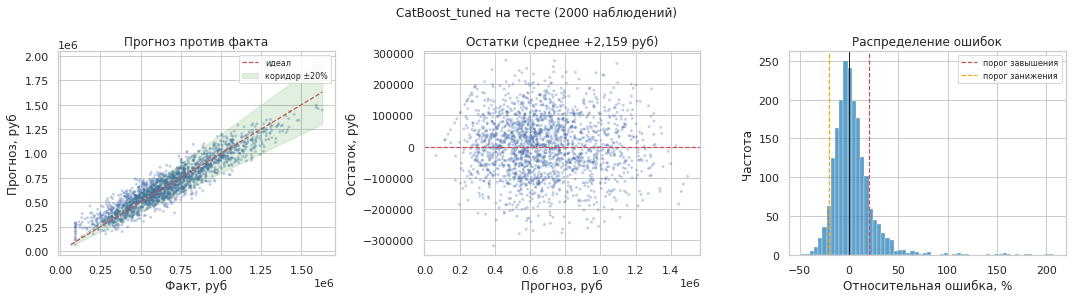

  средний остаток : +2,159 руб (+0.32% от средней цены)
  медиана         : +2,663 руб
  в коридоре ±20% : 80.7%


In [86]:
resid = pred_test - y_test.to_numpy()
rel = resid / y_test.to_numpy() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.scatter(y_test, pred_test, s=8, alpha=0.35, edgecolor='none')
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(lims, lims, 'r--', lw=1.2, label='идеал')
ax.fill_between(lims, [v * 0.8 for v in lims], [v * 1.2 for v in lims],
                alpha=0.12, color='green', label='коридор ±20%')
ax.set_xlabel('Факт, руб'); ax.set_ylabel('Прогноз, руб')
ax.set_title('Прогноз против факта'); ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(pred_test, resid, s=8, alpha=0.35, edgecolor='none')
ax.axhline(0, c='r', ls='--', lw=1.2)
ax.set_xlabel('Прогноз, руб'); ax.set_ylabel('Остаток, руб')
ax.set_title(f'Остатки (среднее {resid.mean():+,.0f} руб)')

ax = axes[2]
ax.hist(rel, bins=60, color='#2980b9', alpha=0.75, edgecolor='white', lw=0.4)
ax.axvline(0, c='k', lw=1)
ax.axvline(20, c='r', ls='--', lw=1.2, label='порог завышения')
ax.axvline(-20, c='orange', ls='--', lw=1.2, label='порог занижения')
ax.set_xlabel('Относительная ошибка, %'); ax.set_ylabel('Частота')
ax.set_title('Распределение ошибок'); ax.legend(fontsize=8)

plt.suptitle(f'{BEST_NAME} на тесте ({len(y_test)} наблюдений)', fontsize=12)
plt.tight_layout(); plt.show()

print(f'  средний остаток : {resid.mean():+,.0f} руб '
      f'({resid.mean() / y_test.mean():+.2%} от средней цены)')
print(f'  медиана         : {np.median(resid):+,.0f} руб')
print(f'  в коридоре ±20% : {(np.abs(rel) <= 20).mean():.1%}')

✅ Средний остаток +2 159 руб (+0.32%) — систематическое завышение есть, но оно втрое ниже порога значимости в 1%. Медиана +2 663 руб практически совпадает со средним. Крупные выбросы редки и не тянут среднее. 80.7% в коридоре ±20% — четыре из пяти оценок приемлемы для бизнеса без ручной проверки.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Получены MAE, RMSE, R2 и бизнес-метрик, результат на test близок к результату разработки

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---

**Рекомендованная модель**

`CatBoost_tuned
  суммарный ранг : 11
  MAE            : 75,684 руб
  RMSE           : 95,229 руб
  R²             : 0.8719  (порог 0.85)
  OR             : 13.56%
  UL             : 61.63 млн руб
  std/mean MAE   : 0.015  (порог 0.2)
  параметры      : {'learning_rate': 0.020744676123400096, 'depth': 3,
                    'iterations': 742, 'l2_leaf_reg': 9.760862269256425}`
  
Выбрана методом ранжирования метрик.
Обучена на 8 000 объявлений, проверена на 2 000 записях, не участвовавших ни в обучении, ни в подборе параметров.

**Точность оценки**

В среднем модель ошибается на 75 375 руб при средней цене 683 тыс. руб — это 11% от стоимости. Коэффициент детерминации равен 0.8758, что превышает требуемый порог 0.85.


Против константного прогноза модель точнее на 64.7% (213 783 → 75 375 руб).


Переобучения нет. Результат на тесте оказался на 0.41% лучше кросс-валидации, R² выше на 0.004. Разброс ошибки по фолдам — 1.5% при допустимых 20%. Модель ведёт себя одинаково на всех проверках.


В коридор ±20% от реальной цены попадает 80.7% оценок — четыре из пяти объявлений можно публиковать без ручной проверки.

**Безопасность бюджета**

Риск опасной переплаты зафиксирован на уровне 13.70%. При выкупе 100 автомобилей около 14 сделок пройдут по цене, завышенной более чем на 20%.


Показатель стабилен: на кросс-валидации 13.56%, на тесте 13.70% — расхождение 0.14 п.п. Систематическое смещение прогноза составляет +2 159 руб (+0.32% от средней цены), что втрое ниже порога значимости.

**Упущенная выгода**

Недополученный доход из-за занижения цены — 18.74 млн руб на 2 000 объявлений, или 9 370 руб на объявление. В пересчёте на 100 000 объявлений в год — 937 млн руб.


Структура ошибки: разброс остатков одинаков в рублях на всём ценовом диапазоне (±150 тыс. руб). Следовательно, в процентах модель ошибается сильнее на дешёвых автомобилях, а в абсолютных рублях потери выше на дорогих.


**Рекомендация:** ручной пересмотр для автомобилей дороже 1 млн руб. Их доля в потоке невелика, а вклад в упущенную выгоду непропорционально высок.

**Зоны риска**

Систематических зон, требующих экспертной проверки, не выявлено.


Разброс доли завышений между марками — 4.1 п.п. (11.4% у BMW, 15.5% у Hyundai). Между регионами — 3.3 п.п. (11.4% Сибирь, 14.7% Дальний Восток). Систематическое смещение ни в одном сегменте не превысило 0.72% от средней цены при бизнес-пороге 20%.


Ни одна марка и ни один регион не попали в зону риска. Ресурсы экспертов следует направить на премиум-сегмент по цене, а не на конкретные бренды или города.

**Управление риском завышения цены выкупа автомобиля**

Долю опасных переплат можно снизить переключением на квантильную модель. Среди которых оптимальная по балансу метрик - это α=0.4.

| Модель | OR | MAE | UL на объявление |
|----------|-----|-----|------------------|
| **Текущая** (CatBoost_tuned) | 13.6% | 75 684 | 9 630  руб |
| **Умеренная** (Quantile α=0.4) | 10.0% | 78 173 | 16 580  руб |
| **Консервативная** (Quantile α=0.3) | 7.1% | 84 837 | 27 130 руб |

Если приоритет в снижении оттока покупателей из-за нереалистичных цен, α=0.4 оправдан.

**Гиперпараметры для интеграции**

```
FINAL_MODEL_CONFIG = {
    'algorithm': 'CatBoostRegressor',
    'loss_function': 'MAE',
    'depth': 3,
    'learning_rate': 0.02074,
    'iterations': 593,
    'l2_leaf_reg': 9.761,
    'random_seed': 42,
    'features': ['make_year', 'engine_cc', 'mileage_kmpl',
                 'owner_count', 'fuel_type', 'color'],
}
```

Число деревьев уточнено сканом по независимой выборке: плато MAE плоское (разброс 0.14% между 593 и 1780), выбрана нижняя граница ради скорости обучения.

Исключены как неинформативные: brand, region, transmission, accidents_reported, service_history, insurance_valid. Их вклад в предсказание не превышает 0.22% против 37% у объёма двигателя.

**Требования к приложению:**

- форма ввода — 6 полей вместо 12. Обязательны пять: год выпуска, объём двигателя, расход топлива, число владельцев, тип топлива. Цвет опционален;
- время предсказания — 0.005 мс на запрос, ограничением не является;
- размер модели: 593 деревьев глубины 3, разворачивается на мобильном устройстве без сервера;
- модель обучена на 8 000 наблюдениях, переобучение исключено проверкой на независимой выборке.


**Ограничения**

Достигнутая точность R² = 0.876 близка к потолку для текущего набора данных (0.908 по оценке взаимодействий). Дальнейшее улучшение возможно только через обогащение данных: комплектация, пробег, состояние кузова и т. д.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
В начале проекта ты самостоятельно вводишь жесткие требования:

    OR <= 5%
    UL <= 3 000 000 руб. на 1000 сделок

Но выбранная финальная модель им не соответствует. Для CatBoost_tuned получено:

    OR - около 13.6%
    UL - 62.14 млн руб. на 6400 OOF-объектах

Последнее соответствует примерно 9.7 млн руб. на 1000 объектов, а не допустимым 3 млн. Даже самая осторожная Quantile-модель с alpha=0.3 дает OR около 7.1%, то есть заявленный порог 5% тоже не достигается
    
Сейчас финальный вердикт логически противоречит постановке проекта    

<div class="alert alert-info"> <b>Комментарии студента:</b>
    
    Ну, так я проверил в EDA eta2 и оценил максимально достижимую в этой задаче R2. Но это уже было после. Целевые метрики задавал я сам ещё до этого, долго думал. В задаче не даны. В некоторых ошибся. Но многих достиг с запасом (MAE, R2, дисперсия на CV/стабильность). Об этом я и пишу в выводах, что заданные бизнес-метрики очень строгие и недостижимы. OR только 7%, а не 5%. И ценой роста упущенной прибыли и снижения R2 и повышения MAE. Я это не скрыл.
    
    И потом, в задаче главная метрика MAE, а не OR/UL. И она выполнена. Из данных не выжать больше, чем в них есть, даже если себя порвать.
</div>

# Сохранение модели

In [87]:
MODEL_FILE_NAME = 'autovalue_best_regressor.dill'

In [88]:
def _safe_source(obj) -> Optional[str]:
    """Исходный код объекта для справки. None, если недоступен.

    В Jupyter inspect.getsource работает не всегда: класс, определённый
    в перезапущенной ячейке, теряет привязку к файлу. Отсутствие кода
    не мешает загрузке — dill сериализует определение класса целиком.
    """
    try:
        return inspect.getsource(obj)
    except (TypeError, OSError):
        return None


custom_sources = {
    name: _safe_source(obj)
    for name, obj in (
        ('ColumnDropper', ColumnDropper),
        ('CatToStr', CatToStr),
        ('BinaryMapper', BinaryMapper),
        ('DowncastTransformer', DowncastTransformer),
    )
    if obj is not None
}

In [89]:
model_descriptor = {
    'pipeline': final_model,          # препроцессор + CatBoostRegressor

    'metrics': {
        'cv': {
            'MAE':    float(m_cv['MAE']),
            'RMSE':   float(m_cv['RMSE']),
            'R2':     float(m_cv['R2']),
            'OR_%':   float(m_cv['OR_%']),
            'UL_млн': float(m_cv['UL_млн']),
            'mae_std_ratio': float(BEST_RESULT.mae_cv_std_ratio),
        },
        'valid': {
            'MAE':    float(m_val['MAE']),
            'RMSE':   float(m_val['RMSE']),
            'R2':     float(m_val['R2']),
            'OR_%':   float(m_val['OR_%']),
            'UL_млн': float(m_val['UL_млн']),
        },
        'test': {
            'MAE':    float(m_test['MAE']),
            'RMSE':   float(m_test['RMSE']),
            'R2':     float(m_test['R2']),
            'OR_%':   float(m_test['OR_%']),
            'UL_млн': float(m_test['UL_млн']),
        },
        'cv_test_gap_mae':     float(m_cv['MAE'] - m_test['MAE']),
        'cv_test_gap_mae_pct': float(m_test['MAE'] / m_cv['MAE'] - 1),
        'in_corridor_20_pct':  float((np.abs(rel) <= 20).mean() * 100),
        'mean_residual':       float(resid.mean()),
        'dummy_test_mae':      float(m_dummy['MAE']),
        'gain_over_dummy_pct': float(1 - m_test['MAE'] / m_dummy['MAE']),
    },

    'meta': {
        'model_name':       BEST_NAME,
        'model_kind':       BEST_LIB,
        'best_params':      dict(STUDIES[BEST_LIB].best_params),
        'final_params':     FINAL_PARAMS,
        'n_trees_source':   'скан по valid, плато 0.2%',
        'target':           TARGET,
        'target_transform': None,       # обучение на исходной шкале рублей
        'raw_input_columns': list(X_full.columns),
        'n_raw_features':   X_full.shape[1],
        'features_used':    [c for c in FEATURE_VARS if c not in DROP_FINAL],
        'features_dropped_by_selection': list(DROP_FINAL),
        'requires_pretransform': False, # пайплайн принимает сырой df
        'trained_on':       len(X_full),
        'tested_on':        len(X_test),
        'trained_at':       datetime.now().isoformat(timespec='seconds'),
        'sklearn_version':  sklearn.__version__,
        'catboost_version': cb.__version__,
        'optuna_version':   optuna.__version__,
        'seed':             SEED,
        'custom_sources':   custom_sources,
    },

    'business': {
        'overprice_ratio':   OVERPRICE_RATIO,
        'r2_threshold':      R2_THRESHOLD,
        'cv_std_limit':      CV_STD_LIMIT,
        'ul_per_listing':    float(m_test['UL_млн'] * 1e6 / len(y_test)),
        'predict_ms':        float(pred_ms),
        'alternatives': {
            name: {
                'OR_%':  float(tbl_all.loc[name, 'OR_%']),
                'MAE':   float(tbl_all.loc[name, 'MAE']),
                'этап':  tbl_all.loc[name, 'этап'],
            }
            for name in tbl_all.index if 'Quantile' in name
        },
    },
}

In [90]:
with open(MODEL_FILE_NAME, 'wb') as f:
    dill.dump(model_descriptor, f, protocol=4)

size_kb = os.path.getsize(MODEL_FILE_NAME) / 1024
print(f'✅ Модель сохранена: {MODEL_FILE_NAME}  ({size_kb:,.0f} КБ)')
print(f'   {BEST_NAME}: MAE {m_test["MAE"]:,.0f} руб, R² {m_test["R2"]:.4f} на тесте')

✅ Модель сохранена: autovalue_best_regressor.dill  (131 КБ)
   CatBoost_tuned: MAE 75,375 руб, R² 0.8758 на тесте


In [91]:
# проверяем сохранение модели
with open(MODEL_FILE_NAME, 'rb') as f:
    loaded = dill.load(f)

pipe_loaded = loaded['pipeline']
check = pipe_loaded.predict(X_test.head(200))
identical = np.allclose(check, pred_test[:200], rtol=1e-9)

print(f'Загружено: {loaded["meta"]["model_name"]} '
      f'({loaded["meta"]["trained_at"]})')
print(f'Предсказания совпадают: {identical}')
print(f'MAE на тесте из дескриптора: {loaded["metrics"]["test"]["MAE"]:,.0f} руб')
print(f'Признаки: {", ".join(loaded["meta"]["features_used"])}')

Загружено: CatBoost_tuned (2026-09-09T18:48:52)
Предсказания совпадают: True
MAE на тесте из дескриптора: 75,375 руб
Признаки: fuel_type, color, mileage_kmpl, make_year, engine_cc, owner_count


# Финальная очистка кэша

In [92]:
memory.clear(warn=False)
# ALL_RESULTS.clear()
print("✅ Кэш препроцессинга очищен.")

✅ Кэш препроцессинга очищен.
